In [1]:
# Core imports
from pathlib import Path
import json
import os
import platform
import random
import warnings
import zipfile

import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report,
    log_loss,
    roc_auc_score,
)
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

ARTIFACT_DIR = Path("artifacts")
(ARTIFACT_DIR / "metrics").mkdir(parents=True, exist_ok=True)
(ARTIFACT_DIR / "plots").mkdir(parents=True, exist_ok=True)
(ARTIFACT_DIR / "submissions").mkdir(parents=True, exist_ok=True)
(ARTIFACT_DIR / "models").mkdir(parents=True, exist_ok=True)

print("Python:", platform.python_version())
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)

Python: 3.13.7
Pandas: 3.0.3
NumPy: 2.5.0


In [2]:
def find_data_dir():
    required = ["train_data.csv", "test_data.csv", "sample_submission.csv"]

    # Optional local extraction. This is useful outside Kaggle when the uploaded file is a zip.
    zip_candidates = [
        Path("/mnt/data/fite-classification-challenge.zip"),
        Path("fite-classification-challenge.zip"),
    ]
    for zip_path in zip_candidates:
        if zip_path.exists():
            extract_dir = zip_path.parent / "fite_extracted"
            if not extract_dir.exists():
                extract_dir.mkdir(parents=True, exist_ok=True)
                with zipfile.ZipFile(zip_path, "r") as zf:
                    zf.extractall(extract_dir)

    candidates = [
        Path("/kaggle/input/fite-classification-challenge"),
        Path("/kaggle/input"),
        Path("/mnt/data/fite_extracted"),
        Path("/mnt/data/fite"),
        Path("."),
    ]

    for base in candidates:
        if not base.exists():
            continue

        # Check base itself.
        if base.is_dir() and all((base / f).exists() for f in required):
            return base

        # Check subdirectories.
        if base.is_dir():
            for train_path in base.rglob("train_data.csv"):
                folder = train_path.parent
                if all((folder / f).exists() for f in required):
                    return folder

    raise FileNotFoundError(
        "Could not find train_data.csv, test_data.csv, and sample_submission.csv. "
        "Set DATA_DIR manually."
    )

DATA_DIR = find_data_dir()
print("DATA_DIR =", DATA_DIR)

DATA_DIR = fite_extracted


In [3]:
train = pd.read_csv(DATA_DIR / "train_data.csv")
test = pd.read_csv(DATA_DIR / "test_data.csv")
sample_submission = pd.read_csv(DATA_DIR / "sample_submission.csv")

print("train shape:", train.shape)
print("test shape:", test.shape)
print("sample submission shape:", sample_submission.shape)

display(train.head())
display(test.head())
display(sample_submission.head())

train shape: (3200, 23)
test shape: (3200, 22)
sample submission shape: (3200, 2)


,ID,f1,f2,f3,f4,f5,f6,f7,f8,f9,...,f13,f14,f15,f16,f17,f18,f19,f20,f21,target
0,1,0.38,0.0160,0,0,0,0,0,0,0.10800,...,0,0.12700,0,1,0,0,0,0.085,0,class3
1,2,0.37,0.0250,0,0,0,0,0,0,0.08400,...,0,0.08000,0,0,0,0,0,0.104,0,class3
2,3,0.57,0.0220,0,0,0,0,0,0,0.11118,...,0,0.11207,0,0,0,0,0,0.099,0,class3
3,4,0.54,0.0206,0,1,0,0,0,0,0.10100,...,0,0.15800,0,0,0,0,0,0.064,0,class3
4,5,0.42,0.0208,0,0,0,0,0,0,0.12300,...,0,0.10400,0,0,0,0,0,0.116,0,class2


,ID,f1,f2,f3,f4,f5,f6,f7,f8,f9,...,f12,f13,f14,f15,f16,f17,f18,f19,f20,f21
0,10000,0.57,0.023,0,1,0,0,0,0,0.115,...,1,1,0.11954,0,0,0,0,0,0.096,0
1,10001,0.54,0.013,1,0,0,0,0,0,0.102,...,0,0,0.11300,0,0,0,0,0,0.091,0
2,10002,0.56,0.019,0,1,0,0,0,0,0.096,...,0,0,0.10300,0,0,0,0,0,0.093,0
3,10003,0.26,0.023,1,0,0,0,0,0,0.096,...,0,0,0.12300,0,0,0,0,0,0.078,0
4,10004,0.60,0.023,0,1,1,0,0,0,0.155,...,1,0,0.22100,0,0,0,1,0,0.070,0


,ID,target
0,10000,class3
1,10001,class1
2,10002,class3
3,10003,class3
4,10004,class1


In [4]:
feature_cols = [c for c in train.columns if c.startswith("f")]
expected_train_cols = ["ID"] + feature_cols + ["target"]
expected_test_cols = ["ID"] + feature_cols
expected_submission_cols = ["ID", "target"]

schema_checks = {
    "has_ID_train": "ID" in train.columns,
    "has_ID_test": "ID" in test.columns,
    "has_target_train": "target" in train.columns,
    "n_features": len(feature_cols),
    "same_features_train_test": feature_cols == [c for c in test.columns if c.startswith("f")],
    "sample_submission_columns_ok": list(sample_submission.columns) == expected_submission_cols,
    "test_ids_match_sample_submission": test["ID"].equals(sample_submission["ID"]),
}

schema_checks

{'has_ID_train': True,
 'has_ID_test': True,
 'has_target_train': True,
 'n_features': 21,
 'same_features_train_test': True,
 'sample_submission_columns_ok': True,
 'test_ids_match_sample_submission': True}

In [5]:
assert schema_checks["has_ID_train"]
assert schema_checks["has_ID_test"]
assert schema_checks["has_target_train"]
assert schema_checks["n_features"] == 21
assert schema_checks["same_features_train_test"]
assert schema_checks["sample_submission_columns_ok"]
assert schema_checks["test_ids_match_sample_submission"]

print("Schema validation passed.")

Schema validation passed.


In [6]:
data_quality = {
    "train_rows": int(train.shape[0]),
    "train_cols": int(train.shape[1]),
    "test_rows": int(test.shape[0]),
    "test_cols": int(test.shape[1]),
    "train_missing_values": int(train.isna().sum().sum()),
    "test_missing_values": int(test.isna().sum().sum()),
    "train_duplicate_IDs": int(train["ID"].duplicated().sum()),
    "test_duplicate_IDs": int(test["ID"].duplicated().sum()),
    "train_duplicate_feature_rows": int(train.duplicated(feature_cols).sum()),
    "test_duplicate_feature_rows": int(test.duplicated(feature_cols).sum()),
}

data_quality

{'train_rows': 3200,
 'train_cols': 23,
 'test_rows': 3200,
 'test_cols': 22,
 'train_missing_values': 0,
 'test_missing_values': 0,
 'train_duplicate_IDs': 0,
 'test_duplicate_IDs': 0,
 'train_duplicate_feature_rows': 57,
 'test_duplicate_feature_rows': 7}

,target,count,share,share_pct
0,class3,2916,0.911250,91.125
1,class2,191,0.059687,5.969
2,class1,93,0.029063,2.906


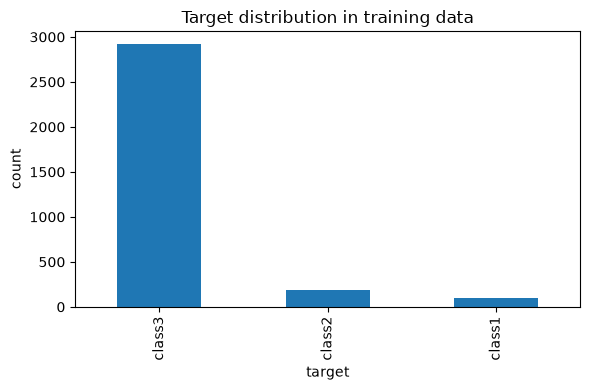

In [7]:
target_distribution = (
    train["target"]
    .value_counts()
    .rename_axis("target")
    .reset_index(name="count")
)
target_distribution["share"] = target_distribution["count"] / len(train)
target_distribution["share_pct"] = (100 * target_distribution["share"]).round(3)

display(target_distribution)

plt.figure(figsize=(6, 4))
train["target"].value_counts().plot(kind="bar")
plt.title("Target distribution in training data")
plt.xlabel("target")
plt.ylabel("count")
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / "plots" / "target_distribution.png", dpi=150)
plt.show()

In [8]:
feature_profile = []
for col in feature_cols:
    train_unique = train[col].nunique(dropna=False)
    test_unique = test[col].nunique(dropna=False)
    values = sorted(train[col].dropna().unique().tolist())
    inferred_type = "binary" if train_unique <= 2 and set(values).issubset({0, 1}) else "numeric"
    feature_profile.append({
        "feature": col,
        "dtype": str(train[col].dtype),
        "train_unique": int(train_unique),
        "test_unique": int(test_unique),
        "inferred_type": inferred_type,
        "train_mean": float(train[col].mean()),
        "test_mean": float(test[col].mean()),
        "abs_mean_shift": float(abs(train[col].mean() - test[col].mean())),
    })

feature_profile = pd.DataFrame(feature_profile)
continuous_features = feature_profile.loc[feature_profile["inferred_type"] == "numeric", "feature"].tolist()
binary_features = feature_profile.loc[feature_profile["inferred_type"] == "binary", "feature"].tolist()

print("Continuous/numeric features:", continuous_features)
print("Binary features:", binary_features)

display(feature_profile)
feature_profile.to_csv(ARTIFACT_DIR / "metrics" / "feature_profile.csv", index=False)

Continuous/numeric features: ['f1', 'f2', 'f9', 'f10', 'f14', 'f20']
Binary features: ['f3', 'f4', 'f5', 'f6', 'f7', 'f8', 'f11', 'f12', 'f13', 'f15', 'f16', 'f17', 'f18', 'f19', 'f21']


,feature,dtype,train_unique,test_unique,inferred_type,train_mean,test_mean,abs_mean_shift
0,f1,float64,92,93,numeric,0.516861,0.526824,0.009963
1,f2,float64,69,70,numeric,0.020118,0.019717,0.000402
2,f3,int64,2,2,binary,0.045000,0.046562,0.001563
3,f4,int64,2,2,binary,0.301250,0.302500,0.001250
4,f5,int64,2,2,binary,0.014687,0.019062,0.004375
5,f6,int64,2,2,binary,0.038750,0.037187,0.001563
6,f7,int64,2,2,binary,0.005000,0.020938,0.015938
7,f8,int64,2,2,binary,0.012188,0.018437,0.006250
8,f9,float64,242,240,numeric,0.107968,0.110992,0.003023
9,f10,float64,271,270,numeric,0.005164,0.005146,0.000019


In [9]:
summary_by_target = train.groupby("target")[continuous_features].agg(["mean", "median", "std", "min", "max"])
display(summary_by_target)

f1                                     f2                    \
            mean median       std   min   max      mean  median       std   
target                                                                      
class1  0.498710   0.51  0.187270  0.01  0.84  0.009658  0.0090  0.006346   
class2  0.524293   0.56  0.194329  0.01  0.88  0.017463  0.0174  0.006018   
class3  0.516953   0.54  0.189591  0.01  0.94  0.020626  0.0206  0.007324   

                        ...       f14                                   \
           min     max  ...      mean median       std      min    max   
target                  ...                                              
class1  0.0020  0.0260  ...  0.033039  0.033  0.020150  0.00200  0.064   
class2  0.0030  0.0410  ...  0.092124  0.091  0.018425  0.06493  0.153   
class3  0.0005  0.1059  ...  0.113494  0.110  0.032188  0.01700  0.612   

             f20                                 
            mean median       std    min    max  
target                                           
class1  0.103753  0.104  0.018271  0.061  0.150  
class2  0.099963  0.100  0.017355  0.056  0.165  
class3  0.099042  0.099  0.018569  0.019  0.232  

[3 rows x 30 columns]

In [10]:
binary_rates_by_target = train.groupby("target")[binary_features].mean()
display(binary_rates_by_target)

,f3,f4,f5,f6,f7,f8,f11,f12,f13,f15,f16,f17,f18,f19,f21
target,,,,,,,,,,,,,,,
class1,0.000000,0.236559,0.021505,0.000000,0.000000,0.000000,0.021505,0.096774,0.118280,0.000000,0.00000,0.021505,0.032258,0.000000,0.000000
class2,0.041885,0.219895,0.015707,0.057592,0.005236,0.015707,0.031414,0.000000,0.141361,0.005236,0.00000,0.000000,0.062827,0.000000,0.000000
class3,0.046639,0.308642,0.014403,0.038752,0.005144,0.012346,0.025034,0.131687,0.054870,0.012003,0.00823,0.013374,0.060014,0.000343,0.014746


In [11]:
try:
    from scipy.stats import ks_2samp
    has_scipy = True
except Exception:
    has_scipy = False

shift_rows = []
for col in feature_cols:
    row = {
        "feature": col,
        "inferred_type": feature_profile.set_index("feature").loc[col, "inferred_type"],
        "train_mean": float(train[col].mean()),
        "test_mean": float(test[col].mean()),
        "mean_diff_test_minus_train": float(test[col].mean() - train[col].mean()),
        "abs_mean_diff": float(abs(test[col].mean() - train[col].mean())),
    }
    if has_scipy and col in continuous_features:
        ks = ks_2samp(train[col], test[col])
        row["ks_stat"] = float(ks.statistic)
        row["ks_pvalue"] = float(ks.pvalue)
    else:
        row["ks_stat"] = np.nan
        row["ks_pvalue"] = np.nan
    shift_rows.append(row)

shift_df = pd.DataFrame(shift_rows).sort_values("abs_mean_diff", ascending=False)
display(shift_df)
shift_df.to_csv(ARTIFACT_DIR / "metrics" / "train_test_shift.csv", index=False)

,feature,inferred_type,train_mean,test_mean,mean_diff_test_minus_train,abs_mean_diff,ks_stat,ks_pvalue
17,f18,binary,0.059375,0.077188,0.017813,0.017813,NaN,NaN
11,f12,binary,0.122813,0.139375,0.016562,0.016562,NaN,NaN
6,f7,binary,0.005000,0.020938,0.015938,0.015938,NaN,NaN
0,f1,numeric,0.516861,0.526824,0.009963,0.009963,0.027187,1.876995e-01
12,f13,binary,0.061875,0.069687,0.007812,0.007812,NaN,NaN
13,f14,numeric,0.109880,0.116732,0.006852,0.006852,0.151562,1.814175e-32
7,f8,binary,0.012188,0.018437,0.006250,0.006250,NaN,NaN
20,f21,binary,0.013437,0.007500,-0.005938,0.005938,NaN,NaN
4,f5,binary,0.014687,0.019062,0.004375,0.004375,NaN,NaN
8,f9,numeric,0.107968,0.110992,0.003023,0.003023,0.093438,1.418990e-12


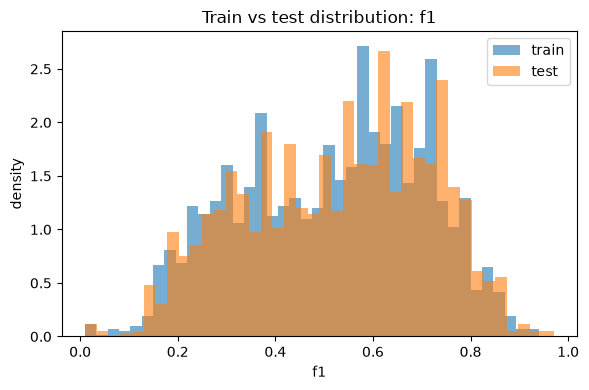

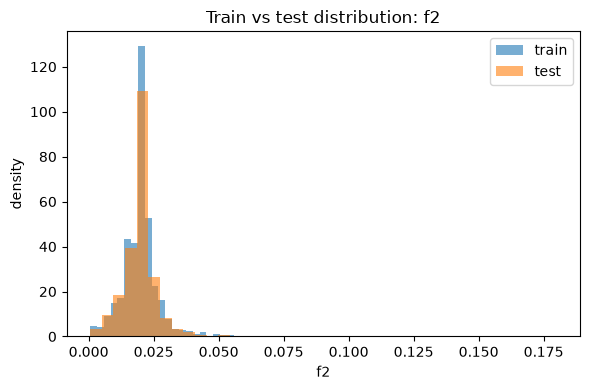

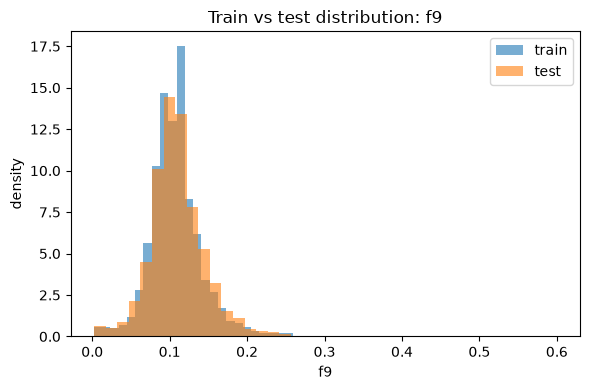

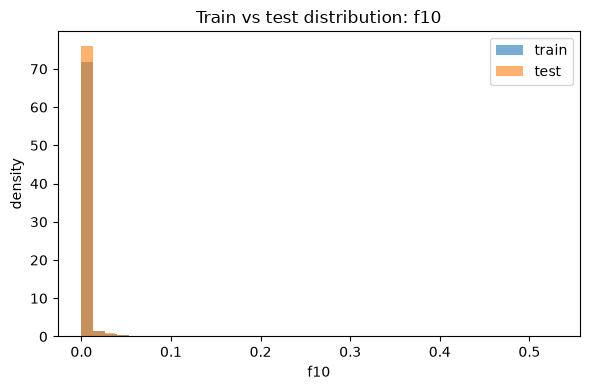

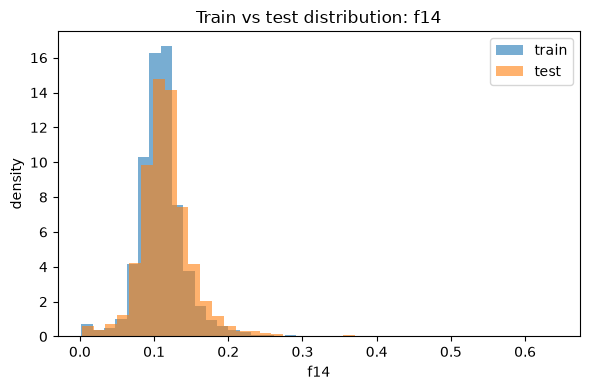

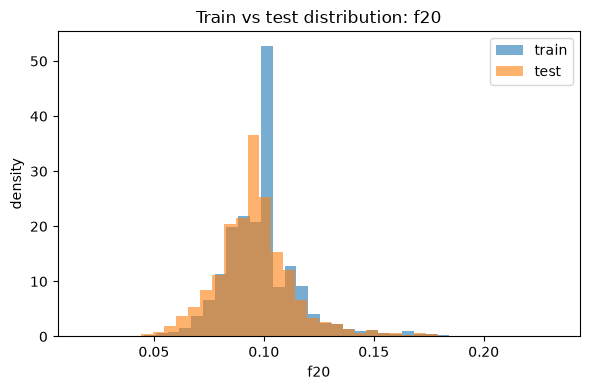

In [12]:
for col in continuous_features:
    plt.figure(figsize=(6, 4))
    train[col].plot(kind="hist", bins=40, alpha=0.6, density=True, label="train")
    test[col].plot(kind="hist", bins=40, alpha=0.6, density=True, label="test")
    plt.title(f"Train vs test distribution: {col}")
    plt.xlabel(col)
    plt.ylabel("density")
    plt.legend()
    plt.tight_layout()
    plt.savefig(ARTIFACT_DIR / "plots" / f"train_test_hist_{col}.png", dpi=150)
    plt.show()

In [13]:
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(train["target"])
class_names = label_encoder.classes_.tolist()
X = train[feature_cols].copy()
X_test = test[feature_cols].copy()

print("Classes:", class_names)
print("Encoded mapping:", dict(zip(class_names, range(len(class_names)))))

Classes: ['class1', 'class2', 'class3']
Encoded mapping: {'class1': 0, 'class2': 1, 'class3': 2}


In [14]:
def evaluate_predictions(y_true, y_pred, y_proba=None, labels=None):
    # Return a dictionary of metrics for multiclass classification.
    metrics = {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "macro_f1": float(f1_score(y_true, y_pred, average="macro")),
        "confusion_matrix": confusion_matrix(y_true, y_pred).tolist(),
    }
    if y_proba is not None:
        metrics["log_loss"] = float(log_loss(y_true, y_proba, labels=labels))
    return metrics

In [15]:
X_train_holdout, X_valid_holdout, y_train_holdout, y_valid_holdout = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Holdout train shape:", X_train_holdout.shape)
print("Holdout valid shape:", X_valid_holdout.shape)
print("Holdout validation class distribution:")
print(pd.Series(y_valid_holdout).map(dict(enumerate(class_names))).value_counts(normalize=True))

Holdout train shape: (2560, 21)
Holdout valid shape: (640, 21)
Holdout validation class distribution:
class3    0.910937
class2    0.059375
class1    0.029687
Name: proportion, dtype: float64


In [16]:
random_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for fold, (_, valid_idx) in enumerate(random_cv.split(X, y), start=1):
    fold_targets = pd.Series(y[valid_idx]).map(dict(enumerate(class_names))).value_counts(normalize=True)
    print(f"Fold {fold}")
    print(fold_targets)
    print()

Fold 1
class3    0.912500
class2    0.059375
class1    0.028125
Name: proportion, dtype: float64

Fold 2
class3    0.910937
class2    0.060937
class1    0.028125
Name: proportion, dtype: float64

Fold 3
class3    0.910937
class2    0.059375
class1    0.029687
Name: proportion, dtype: float64

Fold 4
class3    0.910937
class2    0.059375
class1    0.029687
Name: proportion, dtype: float64

Fold 5
class3    0.910937
class2    0.059375
class1    0.029687
Name: proportion, dtype: float64



In [17]:
def make_id_block_folds(df, n_splits=5, id_col="ID"):
    # Create validation folds from contiguous sorted ID blocks.
    sorted_indices = df.sort_values(id_col).index.to_numpy()
    blocks = np.array_split(sorted_indices, n_splits)
    folds = []
    all_indices = df.index.to_numpy()
    for block in blocks:
        valid_idx = block
        train_idx = np.setdiff1d(all_indices, valid_idx)
        folds.append((train_idx, valid_idx))
    return folds    

id_block_folds = make_id_block_folds(train, n_splits=5, id_col="ID")

for fold, (_, valid_idx) in enumerate(id_block_folds, start=1):
    fold_targets = train.loc[valid_idx, "target"].value_counts(normalize=True)
    id_min = train.loc[valid_idx, "ID"].min()
    id_max = train.loc[valid_idx, "ID"].max()
    print(f"Fold {fold}: ID range {id_min} to {id_max}")
    print(fold_targets)
    print()

Fold 1: ID range 1 to 640
target
class3    0.885938
class2    0.087500
class1    0.026562
Name: proportion, dtype: float64

Fold 2: ID range 641 to 1280
target
class3    0.928125
class2    0.043750
class1    0.028125
Name: proportion, dtype: float64

Fold 3: ID range 1281 to 1920
target
class3    0.918750
class2    0.051562
class1    0.029687
Name: proportion, dtype: float64

Fold 4: ID range 1921 to 2560
target
class3    0.903125
class2    0.067187
class1    0.029687
Name: proportion, dtype: float64

Fold 5: ID range 2561 to 3200
target
class3    0.920312
class2    0.048438
class1    0.031250
Name: proportion, dtype: float64



In [18]:
def run_cv_model(model, X, y, folds, model_name="model", class_names=None):
    # Train and evaluate a model on provided folds.
    # Works for models with predict() and optionally predict_proba().
    n_classes = len(np.unique(y))
    oof_pred = np.zeros(len(y), dtype=int)
    oof_proba = np.zeros((len(y), n_classes))
    has_proba = hasattr(model, "predict_proba")

    fold_metrics = []

    for fold, (train_idx, valid_idx) in enumerate(folds, start=1):
        # clone without importing sklearn.clone in notebook flow
        from sklearn.base import clone
        clf = clone(model)
        clf.fit(X.iloc[train_idx], y[train_idx])

        pred = clf.predict(X.iloc[valid_idx])
        oof_pred[valid_idx] = pred

        if has_proba:
            proba = clf.predict_proba(X.iloc[valid_idx])
            oof_proba[valid_idx] = proba
            metrics = evaluate_predictions(y[valid_idx], pred, proba, labels=list(range(n_classes)))
        else:
            metrics = evaluate_predictions(y[valid_idx], pred)

        metrics["fold"] = fold
        metrics["model"] = model_name
        fold_metrics.append(metrics)

    final_metrics = evaluate_predictions(
        y,
        oof_pred,
        oof_proba if has_proba else None,
        labels=list(range(n_classes)) if has_proba else None,
    )
    final_metrics["model"] = model_name
    final_metrics["n_folds"] = len(folds)

    return final_metrics, pd.DataFrame(fold_metrics), oof_pred, oof_proba if has_proba else None

In [19]:
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score, make_scorer
def run_adversarial_validation(train_df, test_df, feature_cols, random_state=42):
    X_adv = pd.concat([train_df[feature_cols], test_df[feature_cols]], axis=0).reset_index(drop=True)
    y_adv = np.r_[np.zeros(len(train_df), dtype=int), np.ones(len(test_df), dtype=int)]

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)
    oof_proba = np.zeros(len(X_adv))

 

    adv_models = {
    "RandomForest_depth5": RandomForestClassifier(
        n_estimators=300,
        max_depth=5,
        max_features="sqrt",
        random_state=42,
        n_jobs=-1,
    ),
    "ExtraTrees": ExtraTreesClassifier(
        n_estimators=300,
        max_features="sqrt",
        random_state=42,
        n_jobs=-1,
    ),
    }

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    for name, adv_model in adv_models.items():
        auc_scores = cross_val_score(
            adv_model,
            X_adv,
            y_adv,
            cv=cv,
            scoring="roc_auc",
            n_jobs=-1,
        )

        print(name)
        print("AUC scores:", auc_scores)
        print("Mean AUC:", auc_scores.mean())
        print("Std AUC:", auc_scores.std())
        print()

    importances = []
    for train_idx, valid_idx in cv.split(X_adv, y_adv):
        from sklearn.base import clone
        clf = clone(adv_model)
        clf.fit(X_adv.iloc[train_idx], y_adv[train_idx])
        oof_proba[valid_idx] = clf.predict_proba(X_adv.iloc[valid_idx])[:, 1]
        importances.append(clf.feature_importances_)

    auc = roc_auc_score(y_adv, oof_proba)
    importance_df = pd.DataFrame({
        "feature": feature_cols,
        "adversarial_importance": np.mean(importances, axis=0),
    }).sort_values("adversarial_importance", ascending=False)

    return auc, importance_df

adv_auc, adv_importance = run_adversarial_validation(train, test, feature_cols, RANDOM_STATE)
print("Adversarial validation AUC:", round(adv_auc, 5))
display(adv_importance)

adv_importance.to_csv(ARTIFACT_DIR / "metrics" / "adversarial_feature_importance.csv", index=False)

RandomForest_depth5
AUC scores: [0.60824463 0.83545654 0.78075439 0.7872168  0.76947998]
Mean AUC: 0.7562304687500001
Std AUC: 0.07734817988492639

ExtraTrees
AUC scores: [0.51411743 0.72959473 0.68064331 0.6574939  0.70667725]
Mean AUC: 0.6577053222656251
Std AUC: 0.07577600426912988

Adversarial validation AUC: 0.65595


,feature,adversarial_importance
1,f2,0.182916
9,f10,0.157246
13,f14,0.149902
19,f20,0.148889
8,f9,0.142272
0,f1,0.136009
3,f4,0.015708
11,f12,0.008734
2,f3,0.007922
12,f13,0.007777


### How to interpret adversarial validation

Use this rule of thumb:

| AUC | Interpretation |
|---:|---|
| ~0.50 | Train and test look very similar |
| 0.55–0.65 | Mild shift |
| 0.65–0.80 | Important shift |
| >0.80 | Strong shift; random CV may be misleading |

If the AUC is not close to 0.50, we should be more careful with leaderboard submissions.

In [20]:
level_0_2_summary = {
    "random_state": RANDOM_STATE,
    "data_dir": str(DATA_DIR),
    "schema_checks": schema_checks,
    "data_quality": data_quality,
    "target_distribution": target_distribution.to_dict(orient="records"),
    "feature_cols": feature_cols,
    "continuous_features": continuous_features,
    "binary_features": binary_features,
    "adversarial_validation_auc": float(adv_auc),
}

summary_path = ARTIFACT_DIR / "metrics" / "level_0_2_summary.json"
with open(summary_path, "w") as f:
    json.dump(level_0_2_summary, f, indent=2)

print("Saved:", summary_path)

Saved: artifacts\metrics\level_0_2_summary.json


In [ ]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


DATA_DIR_CANDIDATES = [
    Path("/kaggle/input/fite-classification-challenge"),
    Path("fite_extracted/"),
    Path("."),
]

DATA_DIR = next((p for p in DATA_DIR_CANDIDATES if (p / "train_data.csv").exists()), None)
if DATA_DIR is None:
    raise FileNotFoundError("Could not find train_data.csv. Update DATA_DIR_CANDIDATES or set DATA_DIR manually.")

OUT_DIR = Path("level3_artifacts")
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("Using DATA_DIR:", DATA_DIR)
print("Saving artifacts to:", OUT_DIR.resolve())

Using DATA_DIR: fite_extracted
Saving artifacts to: O:\Projects\ML2\me\level3_artifacts


In [22]:
train = pd.read_csv(DATA_DIR / "train_data.csv").reset_index(drop=True)
test = pd.read_csv(DATA_DIR / "test_data.csv").reset_index(drop=True)
sample_submission = pd.read_csv(DATA_DIR / "sample_submission.csv")

feature_cols = [c for c in train.columns if c.startswith("f")]

X = train[feature_cols]
X_test = test[feature_cols]

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(train["target"])
class_names = list(label_encoder.classes_)

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Number of features:", len(feature_cols))
print("Classes:", class_names)

display(train["target"].value_counts(normalize=True).rename("share").to_frame())

Train shape: (3200, 23)
Test shape: (3200, 22)
Number of features: 21
Classes: ['class1', 'class2', 'class3']


,share
target,
class3,0.911250
class2,0.059687
class1,0.029063


In [23]:
def make_id_block_folds(df: pd.DataFrame, n_splits: int = 5, id_col: str = "ID"):
    """Create validation folds from contiguous sorted ID blocks.

    Returns a list of (train_idx, valid_idx) arrays, compatible with scikit-learn style CV loops.
    We return positional indices, so we will use .iloc later.
    """
    sorted_positions = np.argsort(df[id_col].to_numpy())
    blocks = np.array_split(sorted_positions, n_splits)
    all_positions = np.arange(len(df))
    folds = []

    for block in blocks:
        valid_idx = block
        train_idx = np.setdiff1d(all_positions, valid_idx)
        folds.append((train_idx, valid_idx))

    return folds

stratified_folds = list(
    StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE).split(X, y)
)

id_block_folds = make_id_block_folds(train, n_splits=5, id_col="ID")

validation_splits = {
    "stratified_5fold": stratified_folds,
    "id_block_5fold": id_block_folds,
}

for fold, (_, valid_idx) in enumerate(id_block_folds, start=1):
    id_min = train.iloc[valid_idx]["ID"].min()
    id_max = train.iloc[valid_idx]["ID"].max()
    target_share = train.iloc[valid_idx]["target"].value_counts(normalize=True)
    print(f"Fold {fold}: ID range {id_min} to {id_max}")
    print(target_share)
    print()

Fold 1: ID range 1 to 640
target
class3    0.885938
class2    0.087500
class1    0.026562
Name: proportion, dtype: float64

Fold 2: ID range 641 to 1280
target
class3    0.928125
class2    0.043750
class1    0.028125
Name: proportion, dtype: float64

Fold 3: ID range 1281 to 1920
target
class3    0.918750
class2    0.051562
class1    0.029687
Name: proportion, dtype: float64

Fold 4: ID range 1921 to 2560
target
class3    0.903125
class2    0.067187
class1    0.029687
Name: proportion, dtype: float64

Fold 5: ID range 2561 to 3200
target
class3    0.920312
class2    0.048438
class1    0.031250
Name: proportion, dtype: float64



In [24]:
from __future__ import annotations

import json
import warnings
from pathlib import Path
from time import time

import numpy as np
import pandas as pd

from IPython.display import display

from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    log_loss,
)
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore")
models = {
    "dummy_most_frequent": DummyClassifier(strategy="most_frequent"),

    "logreg_balanced": Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            (
                "model",
                LogisticRegression(
                    max_iter=2000,
                    C=0.3,
                    class_weight="balanced",
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),

    "decision_tree_depth3": DecisionTreeClassifier(
        max_depth=3,
        random_state=RANDOM_STATE,
    ),

    "decision_tree_depth5": DecisionTreeClassifier(
        max_depth=5,
        random_state=RANDOM_STATE,
    ),

    "random_forest_depth6_balanced": RandomForestClassifier(
        n_estimators=120,
        max_depth=6,
        max_features="sqrt",
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
}

try:
    from lightgbm import LGBMClassifier

    models["lightgbm_baseline"] = LGBMClassifier(
        objective="multiclass",
        n_estimators=80,
        learning_rate=0.06,
        num_leaves=11,
        max_depth=4,
        min_child_samples=10,
        reg_lambda=0.5,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=RANDOM_STATE,
        verbose=-1,
        n_jobs=1,
        force_col_wise=True,
    )
except Exception as e:
    print("LightGBM is not available, skipping it. Error:", repr(e))

list(models.keys())

['dummy_most_frequent',
 'logreg_balanced',
 'decision_tree_depth3',
 'decision_tree_depth5',
 'random_forest_depth6_balanced',
 'lightgbm_baseline']

In [25]:
def aligned_predict_proba(model, X_val: pd.DataFrame, n_classes: int):
    """Return predict_proba aligned to global encoded class order.

    This is safer than assuming every fitted fold exposes classes in the same order.
    """
    if not hasattr(model, "predict_proba"):
        return None

    proba = model.predict_proba(X_val)

    model_classes = getattr(model, "classes_", None)
    if model_classes is None and hasattr(model, "named_steps"):
        final_estimator = list(model.named_steps.values())[-1]
        model_classes = getattr(final_estimator, "classes_", None)

    if model_classes is None:
        return proba

    aligned = np.zeros((len(X_val), n_classes))
    for j, cls in enumerate(model_classes):
        aligned[:, int(cls)] = proba[:, j]

    return aligned


def evaluate_model(model_name: str, estimator, validation_name: str, folds):
    fold_rows = []
    oof_pred = np.empty(len(X), dtype=int)
    oof_proba = np.zeros((len(X), len(class_names)))
    start = time()

    for fold, (train_idx, valid_idx) in enumerate(folds, start=1):
        model = clone(estimator)
        model.fit(X.iloc[train_idx], y[train_idx])

        pred = np.asarray(model.predict(X.iloc[valid_idx])).astype(int).ravel()
        proba = aligned_predict_proba(model, X.iloc[valid_idx], len(class_names))
        if proba is None:
            proba = np.eye(len(class_names))[pred]

        oof_pred[valid_idx] = pred
        oof_proba[valid_idx] = proba

        fold_rows.append(
            {
                "model": model_name,
                "validation": validation_name,
                "fold": fold,
                "accuracy": accuracy_score(y[valid_idx], pred),
                "balanced_accuracy": balanced_accuracy_score(y[valid_idx], pred),
                "macro_f1": f1_score(y[valid_idx], pred, average="macro"),
                "log_loss": log_loss(y[valid_idx], proba, labels=np.arange(len(class_names))),
            }
        )

    fold_df = pd.DataFrame(fold_rows)
    summary = {
        "model": model_name,
        "validation": validation_name,
        "accuracy_mean": fold_df["accuracy"].mean(),
        "accuracy_std": fold_df["accuracy"].std(ddof=0),
        "balanced_accuracy_mean": fold_df["balanced_accuracy"].mean(),
        "macro_f1_mean": fold_df["macro_f1"].mean(),
        "log_loss_mean": fold_df["log_loss"].mean(),
        "seconds": time() - start,
    }

    cm = confusion_matrix(y, oof_pred).tolist()
    return summary, fold_df, oof_pred, oof_proba, cm

In [26]:
summaries = []
all_fold_metrics = []
confusion_matrices = {}
oof_predictions = {}

for validation_name, folds in validation_splits.items():
    for model_name, estimator in models.items():
        summary, fold_df, oof_pred, oof_proba, cm = evaluate_model(
            model_name=model_name,
            estimator=estimator,
            validation_name=validation_name,
            folds=folds,
        )

        summaries.append(summary)
        all_fold_metrics.append(fold_df)
        confusion_matrices[f"{model_name}__{validation_name}"] = {
            "classes": class_names,
            "confusion_matrix": cm,
        }
        oof_predictions[f"{model_name}__{validation_name}"] = oof_pred

        print(
            f"{validation_name:18s} | {model_name:30s} | "
            f"acc={summary['accuracy_mean']:.6f} | "
            f"macro_f1={summary['macro_f1_mean']:.6f}"
        )

summary_df = pd.DataFrame(summaries).sort_values(
    ["validation", "accuracy_mean", "macro_f1_mean"],
    ascending=[True, False, False],
)

fold_metrics_df = pd.concat(all_fold_metrics, ignore_index=True)

summary_df.to_csv(OUT_DIR / "level3_model_comparison.csv", index=False)
fold_metrics_df.to_csv(OUT_DIR / "level3_fold_metrics.csv", index=False)

with open(OUT_DIR / "level3_confusion_matrices.json", "w") as f:
    json.dump(confusion_matrices, f, indent=2)

print("Saved experiment logs.")

stratified_5fold   | dummy_most_frequent            | acc=0.911250 | macro_f1=0.317855
stratified_5fold   | logreg_balanced                | acc=0.967188 | macro_f1=0.885333
stratified_5fold   | decision_tree_depth3           | acc=0.993125 | macro_f1=0.976914
stratified_5fold   | decision_tree_depth5           | acc=0.998125 | macro_f1=0.991668
stratified_5fold   | random_forest_depth6_balanced  | acc=0.993438 | macro_f1=0.973361
stratified_5fold   | lightgbm_baseline              | acc=0.997500 | macro_f1=0.991749
id_block_5fold     | dummy_most_frequent            | acc=0.911250 | macro_f1=0.317833
id_block_5fold     | logreg_balanced                | acc=0.965625 | macro_f1=0.877572
id_block_5fold     | decision_tree_depth3           | acc=0.992813 | macro_f1=0.974925
id_block_5fold     | decision_tree_depth5           | acc=0.997188 | macro_f1=0.986751
id_block_5fold     | random_forest_depth6_balanced  | acc=0.994688 | macro_f1=0.980437
id_block_5fold     | lightgbm_baseline     

In [27]:
display(
    summary_df[[
        "validation",
        "model",
        "accuracy_mean",
        "accuracy_std",
        "balanced_accuracy_mean",
        "macro_f1_mean",
        "log_loss_mean",
        "seconds",
    ]].style.format(
        {
            "accuracy_mean": "{:.6f}",
            "accuracy_std": "{:.6f}",
            "balanced_accuracy_mean": "{:.6f}",
            "macro_f1_mean": "{:.6f}",
            "log_loss_mean": "{:.6f}",
            "seconds": "{:.2f}",
        }
    )
)

,validation,model,accuracy_mean,accuracy_std,balanced_accuracy_mean,macro_f1_mean,log_loss_mean,seconds
11,id_block_5fold,lightgbm_baseline,0.997500,0.002539,0.995687,0.989098,0.011836,0.41
9,id_block_5fold,decision_tree_depth5,0.997188,0.003030,0.988593,0.986751,0.102291,0.09
10,id_block_5fold,random_forest_depth6_balanced,0.994688,0.002724,0.994464,0.980437,0.146127,2.96
8,id_block_5fold,decision_tree_depth3,0.992813,0.003217,0.989970,0.974925,0.065272,0.06
7,id_block_5fold,logreg_balanced,0.965625,0.010270,0.942458,0.877572,0.237211,0.28
6,id_block_5fold,dummy_most_frequent,0.911250,0.015033,0.333333,0.317833,3.198874,0.05
3,stratified_5fold,decision_tree_depth5,0.998125,0.002500,0.992330,0.991668,0.039229,0.07
5,stratified_5fold,lightgbm_baseline,0.997500,0.002724,0.995805,0.991749,0.010993,0.39
4,stratified_5fold,random_forest_depth6_balanced,0.993438,0.002688,0.987221,0.973361,0.148458,2.99
2,stratified_5fold,decision_tree_depth3,0.993125,0.003644,0.994090,0.976914,0.045085,0.11


In [28]:
best_row = (
    summary_df[summary_df["validation"] == "stratified_5fold"]
    .sort_values(["accuracy_mean", "macro_f1_mean"], ascending=False)
    .iloc[0]
)

best_model_name = best_row["model"]
print("Best Level 3 baseline:", best_model_name)
display(best_row.to_frame("value"))

best_key = f"{best_model_name}__stratified_5fold"
best_cm = np.array(confusion_matrices[best_key]["confusion_matrix"])

cm_df = pd.DataFrame(best_cm, index=[f"true_{c}" for c in class_names], columns=[f"pred_{c}" for c in class_names])
display(cm_df)

Best Level 3 baseline: decision_tree_depth5


,value
model,decision_tree_depth5
validation,stratified_5fold
accuracy_mean,0.998125
accuracy_std,0.0025
balanced_accuracy_mean,0.99233
macro_f1_mean,0.991668
log_loss_mean,0.039229
seconds,0.071246


,pred_class1,pred_class2,pred_class3
true_class1,91,0,2
true_class2,0,191,0
true_class3,1,3,2912


In [29]:
best_oof_pred = oof_predictions[best_key]

error_analysis = train[["ID", "target"] + feature_cols].copy()
error_analysis["predicted_target"] = label_encoder.inverse_transform(best_oof_pred)
error_analysis["is_error"] = error_analysis["target"] != error_analysis["predicted_target"]

errors_only = error_analysis[error_analysis["is_error"]].copy()
errors_only.to_csv(OUT_DIR / "level3_best_error_analysis.csv", index=False)

print("Number of validation errors:", len(errors_only))
display(errors_only.head(20))

Number of validation errors: 6


,ID,target,f1,f2,f3,f4,f5,f6,f7,f8,...,f14,f15,f16,f17,f18,f19,f20,f21,predicted_target,is_error
598,599,class1,0.29,0.0096,0,0,0,0,0,0,...,0.053,0,0,1,0,0,0.120,0,class3,True
695,696,class1,0.69,0.0200,0,0,0,0,0,0,...,0.059,0,0,0,0,0,0.150,0,class3,True
1737,1738,class3,0.85,0.0240,0,0,0,0,0,0,...,0.061,0,0,0,0,0,0.109,0,class1,True
2268,2269,class3,0.38,0.0469,0,0,0,0,0,0,...,0.445,0,0,0,0,0,0.028,0,class2,True
2425,2426,class3,0.60,0.0206,0,0,0,0,0,0,...,0.096,0,0,0,0,0,0.047,0,class2,True
2457,2458,class3,0.79,0.0340,0,0,0,0,0,0,...,0.102,0,0,0,0,0,0.092,0,class2,True


In [30]:
best_estimator = clone(models[best_model_name])
best_estimator.fit(X, y)

test_pred_encoded = np.asarray(best_estimator.predict(X_test)).astype(int).ravel()
test_pred_labels = label_encoder.inverse_transform(test_pred_encoded)

submission = pd.DataFrame(
    {
        "ID": sample_submission["ID"],
        "target": test_pred_labels,
    }
)

submission_path = OUT_DIR / f"submission_level3_{best_model_name}.csv"
submission.to_csv(submission_path, index=False)

print("Saved submission to:", submission_path)
display(submission.head())

print("Submission target distribution:")
display(submission["target"].value_counts(normalize=False).to_frame("count"))

Saved submission to: level3_artifacts\submission_level3_decision_tree_depth5.csv


,ID,target
0,10000,class3
1,10001,class3
2,10002,class3
3,10003,class3
4,10004,class3


Submission target distribution:


,count
target,
class3,2937
class2,189
class1,74


In [31]:
distribution_rows = []

for model_name, estimator in models.items():
    model = clone(estimator)
    model.fit(X, y)
    pred = np.asarray(model.predict(X_test)).astype(int).ravel()
    pred_labels = label_encoder.inverse_transform(pred)
    counts = pd.Series(pred_labels).value_counts().reindex(class_names, fill_value=0)

    for class_name in class_names:
        distribution_rows.append(
            {
                "model": model_name,
                "target": class_name,
                "count": int(counts[class_name]),
                "share": float(counts[class_name] / len(test)),
            }
        )

test_distribution_df = pd.DataFrame(distribution_rows)
test_distribution_df.to_csv(OUT_DIR / "level3_test_prediction_distributions.csv", index=False)

display(test_distribution_df.pivot(index="model", columns="target", values="count"))

target,class1,class2,class3
model,,,
decision_tree_depth3,81,204,2915
decision_tree_depth5,74,189,2937
dummy_most_frequent,0,0,3200
lightgbm_baseline,81,187,2932
logreg_balanced,110,262,2828
random_forest_depth6_balanced,82,199,2919


In [32]:
train = pd.read_csv(DATA_DIR / "train_data.csv")
test = pd.read_csv(DATA_DIR / "test_data.csv")
sample_submission = pd.read_csv(DATA_DIR / "sample_submission.csv")
feature_cols = [c for c in train.columns if c.startswith("f")]
X = train[feature_cols].copy()
X_test = test[feature_cols].copy()
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(train["target"])
class_names = list(label_encoder.classes_)
print("Train:", train.shape, "Test:", test.shape, "Features:", len(feature_cols))
display(train["target"].value_counts().to_frame("count").assign(percent=lambda d: (100*d["count"]/len(train)).round(3)))

Train: (3200, 23) Test: (3200, 22) Features: 21


,count,percent
target,,
class3,2916,91.125
class2,191,5.969
class1,93,2.906


In [33]:
import json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, classification_report, confusion_matrix, log_loss
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, export_text, _tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

tree_params = dict(
    max_depth=5,
    random_state=RANDOM_STATE,
)

oof_pred = np.zeros(len(train), dtype=int)
oof_proba = np.zeros((len(train), len(class_names)))
oof_fold = np.zeros(len(train), dtype=int)
fold_models = {}
fold_valid_indices = {}
fold_scores = []

for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y), start=1):
    model = DecisionTreeClassifier(**tree_params)
    model.fit(X.iloc[train_idx], y[train_idx])

    pred = model.predict(X.iloc[valid_idx])
    proba = model.predict_proba(X.iloc[valid_idx])

    oof_pred[valid_idx] = pred
    oof_proba[valid_idx] = proba
    oof_fold[valid_idx] = fold
    fold_models[fold] = model
    fold_valid_indices[fold] = valid_idx

    fold_scores.append({
        'fold': fold,
        'accuracy': accuracy_score(y[valid_idx], pred),
        'balanced_accuracy': balanced_accuracy_score(y[valid_idx], pred),
        'macro_f1': f1_score(y[valid_idx], pred, average='macro'),
        'valid_size': len(valid_idx),
    })

fold_scores_df = pd.DataFrame(fold_scores)
display(fold_scores_df)

metrics = {
    'oof_accuracy': float(accuracy_score(y, oof_pred)),
    'oof_balanced_accuracy': float(balanced_accuracy_score(y, oof_pred)),
    'oof_macro_f1': float(f1_score(y, oof_pred, average='macro')),
    'confusion_matrix': confusion_matrix(y, oof_pred).tolist(),
    'class_names': class_names,
}
print(json.dumps(metrics, indent=2))
print(classification_report(y, oof_pred, target_names=class_names, digits=4))

fold_scores_df.to_csv(ARTIFACT_DIR / 'fold_scores.csv', index=False)
with open(ARTIFACT_DIR / 'level4_5_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

,fold,accuracy,balanced_accuracy,macro_f1,valid_size
0,1,0.996875,0.980911,0.985576,640
1,2,1.000000,1.000000,1.000000,640
2,3,1.000000,1.000000,1.000000,640
3,4,0.993750,0.980741,0.972764,640
4,5,1.000000,1.000000,1.000000,640


{
  "oof_accuracy": 0.998125,
  "oof_balanced_accuracy": 0.9923742938478104,
  "oof_macro_f1": 0.9916541388239501,
  "confusion_matrix": [
    [
      91,
      0,
      2
    ],
    [
      0,
      191,
      0
    ],
    [
      1,
      3,
      2912
    ]
  ],
  "class_names": [
    "class1",
    "class2",
    "class3"
  ]
}
              precision    recall  f1-score   support

      class1     0.9891    0.9785    0.9838        93
      class2     0.9845    1.0000    0.9922       191
      class3     0.9993    0.9986    0.9990      2916

    accuracy                         0.9981      3200
   macro avg     0.9910    0.9924    0.9917      3200
weighted avg     0.9981    0.9981    0.9981      3200



In [34]:
pd.set_option('display.max_columns', None)

In [35]:
for fold, model in fold_models.items():
    rules = export_text(model, feature_names=feature_cols)
    path = ARTIFACT_DIR / f'fold_{fold}_decision_tree_depth5_rules.txt'
    path.write_text(rules, encoding='utf-8')
    print(f'Saved fold {fold} rules to:', path)

# Also save a final model trained on all training rows, but do not use it to explain OOF errors.
final_tree = DecisionTreeClassifier(**tree_params)
final_tree.fit(X, y)
(ARTIFACT_DIR / 'final_full_train_decision_tree_depth5_rules.txt').write_text(
    export_text(final_tree, feature_names=feature_cols),
    encoding='utf-8'
)
print('Saved final full-train tree rules too.')

Saved fold 1 rules to: artifacts\fold_1_decision_tree_depth5_rules.txt
Saved fold 2 rules to: artifacts\fold_2_decision_tree_depth5_rules.txt
Saved fold 3 rules to: artifacts\fold_3_decision_tree_depth5_rules.txt
Saved fold 4 rules to: artifacts\fold_4_decision_tree_depth5_rules.txt
Saved fold 5 rules to: artifacts\fold_5_decision_tree_depth5_rules.txt
Saved final full-train tree rules too.


In [36]:
error_mask = oof_pred != y
error_df = train.loc[error_mask, ['ID', 'target'] + feature_cols].copy()
error_df['fold'] = oof_fold[error_mask]
error_df['predicted'] = label_encoder.inverse_transform(oof_pred[error_mask])
error_df['confidence'] = oof_proba[error_mask].max(axis=1)
for i, cls in enumerate(class_names):
    error_df[f'proba_{cls}'] = oof_proba[error_mask, i]
error_df = error_df.sort_values(['fold', 'target', 'predicted', 'ID']).reset_index(drop=True)
error_df.to_csv(ARTIFACT_DIR / 'fold_specific_validation_errors.csv', index=False)
print('Validation errors:', len(error_df))
display(error_df)

Validation errors: 6


,ID,target,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,f12,f13,f14,f15,f16,f17,f18,f19,f20,f21,fold,predicted,confidence,proba_class1,proba_class2,proba_class3
0,599,class1,0.29,0.0096,0,0,0,0,0,0,0.063,0.02400,0,0,0,0.053,0,0,1,0,0,0.120,0,1,class3,1.000000,0.0,0.000000,1.000000
1,2458,class3,0.79,0.0340,0,0,0,0,0,0,0.094,0.01209,0,0,0,0.102,0,0,0,0,0,0.092,0,1,class2,0.987097,0.0,0.987097,0.012903
2,696,class1,0.69,0.0200,0,0,0,0,0,0,0.089,0.02600,0,0,0,0.059,0,0,0,0,0,0.150,0,4,class3,1.000000,0.0,0.000000,1.000000
3,1738,class3,0.85,0.0240,0,0,0,0,0,0,0.066,0.00730,0,0,1,0.061,0,0,0,0,0,0.109,0,4,class1,1.000000,1.0,0.000000,0.000000
4,2269,class3,0.38,0.0469,0,0,0,0,0,0,0.123,0.00790,0,0,0,0.445,0,0,0,0,0,0.028,0,4,class2,0.993506,0.0,0.993506,0.006494
5,2426,class3,0.60,0.0206,0,0,0,0,0,0,0.045,0.00650,0,0,0,0.096,0,0,0,0,0,0.047,0,4,class2,0.993506,0.0,0.993506,0.006494


In [37]:
def decision_path_dataframe(model, sample_row, feature_cols, class_names):
    """Return the node-by-node decision path for a single sample."""
    tree = model.tree_
    x = sample_row[feature_cols].to_frame().T
    node_indicator = model.decision_path(x)
    leaf_id = model.apply(x)[0]
    node_index = node_indicator.indices[node_indicator.indptr[0]:node_indicator.indptr[1]]

    rows = []
    for step, node_id in enumerate(node_index):
        counts = tree.value[node_id][0]
        # In recent sklearn versions value may be proportions; keep as displayed and also normalize safely.
        total = counts.sum()
        probs = counts / total if total > 0 else counts
        predicted_idx = int(np.argmax(counts))
        predicted_class = class_names[predicted_idx]

        if node_id == leaf_id:
            rows.append({
                'step': step,
                'node_id': int(node_id),
                'is_leaf': True,
                'feature': None,
                'operator': None,
                'threshold': None,
                'sample_value': None,
                'decision': 'LEAF',
                'node_prediction': predicted_class,
                **{f'node_value_{cls}': float(counts[i]) for i, cls in enumerate(class_names)},
                **{f'node_prob_{cls}': float(probs[i]) for i, cls in enumerate(class_names)},
            })
        else:
            feature_idx = tree.feature[node_id]
            feature_name = feature_cols[feature_idx]
            threshold = tree.threshold[node_id]
            value = float(sample_row[feature_name])
            go_left = value <= threshold
            rows.append({
                'step': step,
                'node_id': int(node_id),
                'is_leaf': False,
                'feature': feature_name,
                'operator': '<=' if go_left else '>',
                'threshold': float(threshold),
                'sample_value': value,
                'decision': 'left' if go_left else 'right',
                'node_prediction': predicted_class,
                **{f'node_value_{cls}': float(counts[i]) for i, cls in enumerate(class_names)},
                **{f'node_prob_{cls}': float(probs[i]) for i, cls in enumerate(class_names)},
            })
    return pd.DataFrame(rows)


def readable_decision_path(path_df, sample_id, true_label, predicted_label, fold):
    lines = [f'Sample ID {sample_id} | fold {fold} | true={true_label} | predicted={predicted_label}']
    for _, row in path_df.iterrows():
        if row['is_leaf']:
            lines.append(
                f"  Step {int(row['step'])}: Leaf node {int(row['node_id'])} -> "
                f"node predicts {row['node_prediction']} "
                f"(probs: " + ', '.join([f"{cls}={row[f'node_prob_{cls}']:.4f}" for cls in class_names]) + ")"
            )
        else:
            lines.append(
                f"  Step {int(row['step'])}: node {int(row['node_id'])}: "
                f"{row['feature']}={row['sample_value']:.6g} {row['operator']} {row['threshold']:.6g} "
                f"-> go {row['decision']}"
            )
    return '\n'.join(lines)

In [38]:
all_path_rows = []
readable_blocks = []

for _, err in error_df.iterrows():
    sample_id = int(err['ID'])
    fold = int(err['fold'])
    model = fold_models[fold]
    sample_row = train.loc[train['ID'] == sample_id].iloc[0]
    path_df = decision_path_dataframe(model, sample_row, feature_cols, class_names)
    path_df.insert(0, 'ID', sample_id)
    path_df.insert(1, 'fold', fold)
    path_df.insert(2, 'target', err['target'])
    path_df.insert(3, 'predicted', err['predicted'])
    all_path_rows.append(path_df)
    readable_blocks.append(readable_decision_path(path_df, sample_id, err['target'], err['predicted'], fold))

all_paths_df = pd.concat(all_path_rows, ignore_index=True) if all_path_rows else pd.DataFrame()
all_paths_df.to_csv(ARTIFACT_DIR / 'fold_specific_error_decision_paths.csv', index=False)
(ARTIFACT_DIR / 'fold_specific_error_decision_paths_readable.txt').write_text('\n\n'.join(readable_blocks), encoding='utf-8')

print('Saved detailed decision paths:', ARTIFACT_DIR / 'fold_specific_error_decision_paths.csv')
print('Saved readable decision paths:', ARTIFACT_DIR / 'fold_specific_error_decision_paths_readable.txt')
print('\n'.join(readable_blocks[:2]))

Saved detailed decision paths: artifacts\fold_specific_error_decision_paths.csv
Saved readable decision paths: artifacts\fold_specific_error_decision_paths_readable.txt
Sample ID 599 | fold 1 | true=class1 | predicted=class3
  Step 0: node 0: f10=0.024 > 0.00605 -> go right
  Step 1: node 2: f14=0.053 <= 0.064465 -> go left
  Step 2: node 3: f1=0.29 <= 0.845 -> go left
  Step 3: node 4: f17=1 > 0.5 -> go right
  Step 4: node 6: f2=0.0096 <= 0.0164 -> go left
  Step 5: Leaf node 7 -> node predicts class3 (probs: class1=0.0000, class2=0.0000, class3=1.0000)
Sample ID 2458 | fold 1 | true=class3 | predicted=class2
  Step 0: node 0: f10=0.01209 > 0.00605 -> go right
  Step 1: node 2: f14=0.102 > 0.064465 -> go right
  Step 2: node 10: f12=0 <= 0.5 -> go left
  Step 3: node 11: f9=0.094 <= 0.1535 -> go left
  Step 4: node 12: f17=0 <= 0.5 -> go left
  Step 5: Leaf node 13 -> node predicts class2 (probs: class1=0.0000, class2=0.9871, class3=0.0129)


In [39]:
example_id = 599
if example_id in set(error_df['ID']):
    err = error_df.loc[error_df['ID'] == example_id].iloc[0]
    fold = int(err['fold'])
    model = fold_models[fold]
    sample_row = train.loc[train['ID'] == example_id].iloc[0]
    path_599 = decision_path_dataframe(model, sample_row, feature_cols, class_names)
    display(train.loc[train['ID'] == example_id, ['ID', 'target'] + feature_cols])
    display(path_599)
    print(readable_decision_path(path_599, example_id, err['target'], err['predicted'], fold))
else:
    print(f'ID {example_id} is not an OOF error in this run.')

,ID,target,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,f12,f13,f14,f15,f16,f17,f18,f19,f20,f21
598,599,class1,0.29,0.0096,0,0,0,0,0,0,0.063,0.024,0,0,0,0.053,0,0,1,0,0,0.12,0


,step,node_id,is_leaf,feature,operator,threshold,sample_value,decision,node_prediction,node_value_class1,node_value_class2,node_value_class3,node_prob_class1,node_prob_class2,node_prob_class3
0,0,0,False,f10,>,0.006050,0.0240,right,class3,0.029297,0.059766,0.910937,0.029297,0.059766,0.910937
1,1,2,False,f14,<=,0.064465,0.0530,left,class2,0.273723,0.558394,0.167883,0.273723,0.558394,0.167883
2,2,3,False,f1,<=,0.845000,0.2900,left,class1,0.974026,0.000000,0.025974,0.974026,0.000000,0.025974
3,3,4,False,f17,>,0.500000,1.0000,right,class1,0.986842,0.000000,0.013158,0.986842,0.000000,0.013158
4,4,6,False,f2,<=,0.016400,0.0096,left,class1,0.500000,0.000000,0.500000,0.500000,0.000000,0.500000
5,5,7,True,NaN,NaN,NaN,NaN,LEAF,class3,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000


Sample ID 599 | fold 1 | true=class1 | predicted=class3
  Step 0: node 0: f10=0.024 > 0.00605 -> go right
  Step 1: node 2: f14=0.053 <= 0.064465 -> go left
  Step 2: node 3: f1=0.29 <= 0.845 -> go left
  Step 3: node 4: f17=1 > 0.5 -> go right
  Step 4: node 6: f2=0.0096 <= 0.0164 -> go left
  Step 5: Leaf node 7 -> node predicts class3 (probs: class1=0.0000, class2=0.0000, class3=1.0000)


In [40]:
if example_id in set(error_df['ID']):
    sample_row = train.loc[train['ID'] == example_id].iloc[0]
    fold = int(error_df.loc[error_df['ID'] == example_id, 'fold'].iloc[0])
    fold_path = decision_path_dataframe(fold_models[fold], sample_row, feature_cols, class_names)
    final_path = decision_path_dataframe(final_tree, sample_row, feature_cols, class_names)
    print('Fold-specific model path:')
    print(readable_decision_path(fold_path, example_id, sample_row['target'], error_df.loc[error_df['ID'] == example_id, 'predicted'].iloc[0], fold))
    print('\nFinal full-train model path:')
    final_pred = label_encoder.inverse_transform(final_tree.predict(sample_row[feature_cols].to_frame().T))[0]
    print(readable_decision_path(final_path, example_id, sample_row['target'], final_pred, 'full-train'))

Fold-specific model path:
Sample ID 599 | fold 1 | true=class1 | predicted=class3
  Step 0: node 0: f10=0.024 > 0.00605 -> go right
  Step 1: node 2: f14=0.053 <= 0.064465 -> go left
  Step 2: node 3: f1=0.29 <= 0.845 -> go left
  Step 3: node 4: f17=1 > 0.5 -> go right
  Step 4: node 6: f2=0.0096 <= 0.0164 -> go left
  Step 5: Leaf node 7 -> node predicts class3 (probs: class1=0.0000, class2=0.0000, class3=1.0000)

Final full-train model path:
Sample ID 599 | fold full-train | true=class1 | predicted=class1
  Step 0: node 0: f10=0.024 > 0.00605 -> go right
  Step 1: node 2: f14=0.053 <= 0.064465 -> go left
  Step 2: node 3: f20=0.12 <= 0.1425 -> go left
  Step 3: node 4: f1=0.29 <= 0.845 -> go left
  Step 4: Leaf node 5 -> node predicts class1 (probs: class1=1.0000, class2=0.0000, class3=0.0000)


In [41]:
full_tree = DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)
full_tree.fit(X, y)
rule_text = export_text(full_tree, feature_names=feature_cols, decimals=6)
print(rule_text)
with open(ARTIFACT_DIR / "decision_tree_depth5_rules.txt", "w") as f: f.write(rule_text)

|--- f10 <= 0.006050
|   |--- class: 2
|--- f10 >  0.006050
|   |--- f14 <= 0.064465
|   |   |--- f20 <= 0.142500
|   |   |   |--- f1 <= 0.845000
|   |   |   |   |--- class: 0
|   |   |   |--- f1 >  0.845000
|   |   |   |   |--- class: 2
|   |   |--- f20 >  0.142500
|   |   |   |--- f2 <= 0.016000
|   |   |   |   |--- class: 2
|   |   |   |--- f2 >  0.016000
|   |   |   |   |--- class: 0
|   |--- f14 >  0.064465
|   |   |--- f12 <= 0.500000
|   |   |   |--- f9 <= 0.153500
|   |   |   |   |--- f17 <= 0.500000
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- f17 >  0.500000
|   |   |   |   |   |--- class: 2
|   |   |   |--- f9 >  0.153500
|   |   |   |   |--- class: 2
|   |   |--- f12 >  0.500000
|   |   |   |--- class: 2



In [42]:
importance_df = pd.DataFrame({"feature": feature_cols, "tree_importance": full_tree.feature_importances_}).sort_values("tree_importance", ascending=False)
importance_df.to_csv(ARTIFACT_DIR / "level4_feature_importance.csv", index=False)
display(importance_df)

,feature,tree_importance
9,f10,0.626290
13,f14,0.208226
11,f12,0.102734
8,f9,0.030050
16,f17,0.021582
19,f20,0.004783
0,f1,0.003785
1,f2,0.002550
2,f3,0.000000
4,f5,0.000000


In [43]:
tree_ = full_tree.tree_
threshold_rows = []
for node_id in range(tree_.node_count):
    feature_idx = tree_.feature[node_id]
    if feature_idx != _tree.TREE_UNDEFINED:
        threshold_rows.append({
            "node_id": node_id,
            "feature": feature_cols[feature_idx],
            "threshold": tree_.threshold[node_id],
            "samples": tree_.n_node_samples[node_id],
            "impurity": tree_.impurity[node_id],
        })
threshold_df = pd.DataFrame(threshold_rows).sort_values(["feature", "threshold"])
threshold_df.to_csv(ARTIFACT_DIR / "level4_tree_thresholds.csv", index=False)
display(threshold_df)

,node_id,feature,threshold,samples,impurity
3,4,f1,0.845000,93,0.021274
0,0,f10,0.006050,3200,0.165216
5,10,f12,0.500000,247,0.350637
1,2,f14,0.064465,343,0.586813
7,12,f17,0.500000,200,0.085950
4,7,f2,0.016000,3,0.444444
2,3,f20,0.142500,96,0.060547
6,11,f9,0.153500,209,0.157414


In [44]:
train_leaf = full_tree.apply(X)
test_leaf = full_tree.apply(X_test)
leaf_train = pd.DataFrame({"leaf_id": train_leaf, "target": train["target"]})
leaf_summary = leaf_train.groupby("leaf_id").agg(
    train_count=("target", "size"),
    dominant_class=("target", lambda s: s.value_counts().idxmax()),
    dominant_count=("target", lambda s: s.value_counts().max()),
    n_classes=("target", "nunique"),
).reset_index()
leaf_summary["purity"] = leaf_summary["dominant_count"] / leaf_summary["train_count"]
test_leaf_counts = pd.Series(test_leaf).value_counts().rename_axis("leaf_id").reset_index(name="test_count")
leaf_summary = leaf_summary.merge(test_leaf_counts, on="leaf_id", how="outer").fillna({"train_count":0, "test_count":0})
leaf_summary = leaf_summary.sort_values(["purity", "train_count"], ascending=[True, True])
leaf_summary.to_csv(ARTIFACT_DIR / "level4_leaf_summary.csv", index=False)
display(leaf_summary)

,leaf_id,train_count,dominant_class,dominant_count,n_classes,purity,test_count
5,13,194,class2,191,2,0.984536,189.0
2,6,1,class3,1,1,1.000000,7.0
4,9,1,class1,1,1,1.000000,0.0
3,8,2,class3,2,1,1.000000,1.0
6,14,6,class3,6,1,1.000000,4.0
7,15,9,class3,9,1,1.000000,11.0
8,16,38,class3,38,1,1.000000,54.0
1,5,92,class1,92,1,1.000000,74.0
0,1,2857,class3,2857,1,1.000000,2860.0


In [45]:
feature_std = train[feature_cols].std().replace(0, 1)
min_dist = np.full(len(test), np.inf)
closest_feature = np.array([None] * len(test), dtype=object)
closest_threshold = np.full(len(test), np.nan)
for _, row in threshold_df.iterrows():
    feat, thr = row["feature"], row["threshold"]
    dist = np.abs(test[feat].to_numpy() - thr) / feature_std[feat]
    update = dist < min_dist
    min_dist[update] = dist[update]
    closest_feature[update] = feat
    closest_threshold[update] = thr
test_proba_tree = full_tree.predict_proba(X_test)
test_pred_tree = full_tree.predict(X_test)
risk = pd.DataFrame({
    "ID": test["ID"],
    "min_normalized_boundary_distance": min_dist,
    "closest_boundary_feature": closest_feature,
    "closest_boundary_threshold": closest_threshold,
    "tree_prediction": label_encoder.inverse_transform(test_pred_tree),
    "tree_confidence": test_proba_tree.max(axis=1),
}).sort_values("min_normalized_boundary_distance").reset_index(drop=True)
risk.to_csv(ARTIFACT_DIR / "level4_test_boundary_risk.csv", index=False)
display(risk.head(30))
display(risk.groupby("tree_prediction")["min_normalized_boundary_distance"].describe())

,ID,min_normalized_boundary_distance,closest_boundary_feature,closest_boundary_threshold,tree_prediction,tree_confidence
0,10038,2.289325e-08,f2,0.016,class3,1.000000
1,10017,2.289325e-08,f2,0.016,class3,1.000000
2,12952,2.289325e-08,f2,0.016,class3,1.000000
3,11772,2.289325e-08,f2,0.016,class3,1.000000
4,12876,2.289325e-08,f2,0.016,class3,1.000000
5,10078,2.289325e-08,f2,0.016,class3,1.000000
6,12383,2.289325e-08,f2,0.016,class3,1.000000
7,10477,2.289325e-08,f2,0.016,class3,1.000000
8,10419,2.289325e-08,f2,0.016,class3,1.000000
9,13112,2.289325e-08,f2,0.016,class3,1.000000


,count,mean,std,min,25%,50%,75%,max
tree_prediction,,,,,,,,
class1,74.0,0.506465,0.421415,2.289325e-08,0.139997,0.397985,0.855007,1.523122
class2,189.0,0.139356,0.165356,2.289325e-08,0.037828,0.102981,0.157284,1.073118
class3,2937.0,0.155474,0.070689,2.289325e-08,0.125429,0.161266,0.201085,0.993480


## 5 Rule-derived feature engineering

From the Level 4 tree, the most important thresholds were around:

```text
f10 <= 0.00605
f14 <= 0.064465
f20 <= 0.1425
f1  <= 0.845
f2  <= 0.016
f9  <= 0.1535
```

Instead of using only the raw columns, Level 5 adds threshold indicators, distance-to-boundary features, class-region features, and a simple boundary-risk feature.

In [55]:
train = pd.read_csv(DATA_DIR / "train_data.csv").reset_index(drop=True)
test = pd.read_csv(DATA_DIR / "test_data.csv").reset_index(drop=True)

sample_path = DATA_DIR / "sample_submission.csv"
if not sample_path.exists():
    sample_path = DATA_DIR / "random_submission.csv"

sample = pd.read_csv(sample_path)

feature_cols = [c for c in train.columns if c.startswith("f")]
continuous_features = ["f1", "f2", "f9", "f10", "f14", "f20"]
binary_features = [c for c in feature_cols if c not in continuous_features]

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(train["target"])
class_names = list(label_encoder.classes_)

X = train[feature_cols].copy()
X_test = test[feature_cols].copy()

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Number of base features:", len(feature_cols))
print("Classes:", class_names)
display(train["target"].value_counts(normalize=True).rename("target_share").to_frame())

Train shape: (3200, 23)
Test shape: (3200, 22)
Number of base features: 21
Classes: ['class1', 'class2', 'class3']


,target_share
target,
class3,0.911250
class2,0.059687
class1,0.029063


In [56]:
def add_rule_features(df):
    out = df.copy()

    # Thresholds discovered from Level 4 rule mining.
    thresholds = {
        "f10": 0.00605,
        "f14": 0.064465,
        "f20": 0.1425,
        "f1": 0.845,
        "f2": 0.016,
        "f9": 0.1535,
    }

    for feature, threshold in thresholds.items():
        out[f"{feature}_gt_thr"] = (out[feature] > threshold).astype(int)
        out[f"{feature}_dist_thr"] = (out[feature] - threshold).abs()

    out["region_class1_like"] = (
        (out["f10"] > thresholds["f10"])
        & (out["f14"] <= thresholds["f14"])
        & (out["f20"] <= thresholds["f20"])
        & (out["f1"] <= thresholds["f1"])
    ).astype(int)

    out["region_class2_like"] = (
        (out["f10"] > thresholds["f10"])
        & (out["f14"] > thresholds["f14"])
        & (out["f12"] <= 0.5)
        & (out["f9"] <= thresholds["f9"])
        & (out["f17"] <= 0.5)
    ).astype(int)

    out["region_class3_like"] = (
        (out["f10"] <= thresholds["f10"])
        | (
            (out["f10"] > thresholds["f10"])
            & (out["f14"] > thresholds["f14"])
            & (out["f12"] > 0.5)
        )
    ).astype(int)

    out["min_boundary_distance"] = np.minimum.reduce([
        (out["f10"] - thresholds["f10"]).abs(),
        (out["f14"] - thresholds["f14"]).abs(),
        (out["f20"] - thresholds["f20"]).abs(),
        (out["f2"] - thresholds["f2"]).abs(),
        (out["f9"] - thresholds["f9"]).abs(),
    ])

    return out

X_eng = add_rule_features(X)
X_test_eng = add_rule_features(X_test)

print("Base feature count:", X.shape[1])
print("Engineered feature count:", X_eng.shape[1])
print("New engineered features:")
print([c for c in X_eng.columns if c not in X.columns])

Base feature count: 21
Engineered feature count: 37
New engineered features:
['f10_gt_thr', 'f10_dist_thr', 'f14_gt_thr', 'f14_dist_thr', 'f20_gt_thr', 'f20_dist_thr', 'f1_gt_thr', 'f1_dist_thr', 'f2_gt_thr', 'f2_dist_thr', 'f9_gt_thr', 'f9_dist_thr', 'region_class1_like', 'region_class2_like', 'region_class3_like', 'min_boundary_distance']


In [57]:
def make_id_block_folds(df, n_splits=5, id_col="ID"):
    sorted_indices = df.sort_values(id_col).index.to_numpy()
    blocks = np.array_split(sorted_indices, n_splits)
    all_indices = df.index.to_numpy()
    return [(np.setdiff1d(all_indices, block), block) for block in blocks]

folds_random = list(
    StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE).split(X, y)
)
folds_block = make_id_block_folds(train, n_splits=5, id_col="ID")

for fold, (_, valid_idx) in enumerate(folds_block, start=1):
    id_min = train.loc[valid_idx, "ID"].min()
    id_max = train.loc[valid_idx, "ID"].max()
    print(f"ID-block fold {fold}: ID range {id_min} to {id_max}, n={len(valid_idx)}")

ID-block fold 1: ID range 1 to 640, n=640
ID-block fold 2: ID range 641 to 1280, n=640
ID-block fold 3: ID range 1281 to 1920, n=640
ID-block fold 4: ID range 1921 to 2560, n=640
ID-block fold 5: ID range 2561 to 3200, n=640


In [58]:
def adversarial_train_weights():
    all_df = pd.concat([X, X_test], axis=0, ignore_index=True)
    y_adv = np.r_[np.zeros(len(X)), np.ones(len(X_test))]

    adv_model = RandomForestClassifier(
        n_estimators=200,
        max_depth=5,
        max_features="sqrt",
        random_state=RANDOM_STATE,
        n_jobs=1,
    )

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    p_adv = cross_val_predict(
        adv_model,
        all_df,
        y_adv,
        cv=cv,
        method="predict_proba",
        n_jobs=1,
    )[:, 1]

    auc = roc_auc_score(y_adv, p_adv)

    # Convert train probabilities into stable sample weights.
    p_train = np.clip(p_adv[: len(X)], 0.05, 0.95)
    weights = p_train / (1 - p_train)
    weights = weights / np.mean(weights)
    weights = np.clip(weights, 0.5, 2.0)

    weight_df = pd.DataFrame({
        "ID": train["ID"],
        "adv_p_test": p_train,
        "sample_weight": weights,
    })
    weight_df.to_csv(ARTIFACT_DIR / "level5_adversarial_train_weights.csv", index=False)

    return weights, auc

adv_weights, adv_auc = adversarial_train_weights()
print("Adversarial validation AUC:", round(adv_auc, 6))
display(pd.Series(adv_weights, name="sample_weight").describe().to_frame().T)

Adversarial validation AUC: 0.751093


,count,mean,std,min,25%,50%,75%,max
sample_weight,3200.0,0.972809,0.436333,0.5,0.596258,0.883813,1.198959,2.0


In [60]:
from pathlib import Path
import json
import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    log_loss,
    confusion_matrix,
    classification_report,
    roc_auc_score,
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
)
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier

models = {
    "decision_tree_depth4": (
        DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE),
        "base",
        None,
    ),
    "decision_tree_depth5": (
        DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE),
        "base",
        None,
    ),
    "random_forest_depth8_bal": (
        RandomForestClassifier(
            n_estimators=220,
            max_depth=8,
            max_features="sqrt",
            class_weight="balanced_subsample",
            random_state=RANDOM_STATE,
            n_jobs=1,
        ),
        "base",
        None,
    ),
    "extra_trees_bal": (
        ExtraTreesClassifier(
            n_estimators=220,
            max_features="sqrt",
            class_weight="balanced",
            min_samples_leaf=1,
            random_state=RANDOM_STATE,
            n_jobs=1,
        ),
        "base",
        None,
    ),
    "gradient_boosting": (
        GradientBoostingClassifier(
            n_estimators=140,
            learning_rate=0.04,
            max_depth=2,
            random_state=RANDOM_STATE,
        ),
        "base",
        None,
    ),
    "lgbm_regularized": (
        LGBMClassifier(
            objective="multiclass",
            n_estimators=120,
            learning_rate=0.04,
            num_leaves=7,
            max_depth=3,
            min_child_samples=12,
            reg_lambda=2.5,
            subsample=0.9,
            colsample_bytree=0.9,
            random_state=RANDOM_STATE,
            verbose=-1,
            n_jobs=1,
            force_col_wise=True,
        ),
        "base",
        None,
    ),
    "lgbm_engineered": (
        LGBMClassifier(
            objective="multiclass",
            n_estimators=120,
            learning_rate=0.04,
            num_leaves=7,
            max_depth=3,
            min_child_samples=12,
            reg_lambda=2.5,
            subsample=0.9,
            colsample_bytree=0.9,
            random_state=RANDOM_STATE,
            verbose=-1,
            n_jobs=1,
            force_col_wise=True,
        ),
        "eng",
        None,
    ),
    "lgbm_adv_weighted": (
        LGBMClassifier(
            objective="multiclass",
            n_estimators=120,
            learning_rate=0.04,
            num_leaves=7,
            max_depth=3,
            min_child_samples=12,
            reg_lambda=2.5,
            subsample=0.9,
            colsample_bytree=0.9,
            random_state=RANDOM_STATE,
            verbose=-1,
            n_jobs=1,
            force_col_wise=True,
        ),
        "base",
        adv_weights,
    ),
    "logreg_engineered_bal": (
        make_pipeline(
            StandardScaler(),
            LogisticRegression(
                max_iter=2000,
                C=0.25,
                class_weight="balanced",
                random_state=RANDOM_STATE,
            ),
        ),
        "eng",
        None,
    ),
}


def get_data(feature_set):
    if feature_set == "eng":
        return X_eng, X_test_eng
    return X, X_test


def fit_with_optional_weights(model, X_train, y_train, weights=None):
    if weights is None:
        model.fit(X_train, y_train)
    else:
        model.fit(X_train, y_train, sample_weight=weights)
    return model


def evaluate_model(model, feature_set, folds, name, predict_test=False, sample_weights=None):
    X_use, X_test_use = get_data(feature_set)
    oof = np.zeros((len(train), len(class_names)))
    test_proba = np.zeros((len(test), len(class_names))) if predict_test else None
    fold_rows = []
    start = time.time()

    for fold, (train_idx, valid_idx) in enumerate(folds, start=1):
        fitted = clone(model)
        fold_weights = sample_weights[train_idx] if sample_weights is not None else None

        fit_with_optional_weights(
            fitted,
            X_use.iloc[train_idx],
            y[train_idx],
            fold_weights,
        )

        valid_proba = fitted.predict_proba(X_use.iloc[valid_idx])
        oof[valid_idx] = valid_proba
        valid_pred = valid_proba.argmax(axis=1)

        fold_rows.append({
            "model": name,
            "fold": fold,
            "n_valid": len(valid_idx),
            "accuracy": accuracy_score(y[valid_idx], valid_pred),
            "balanced_accuracy": balanced_accuracy_score(y[valid_idx], valid_pred),
            "macro_f1": f1_score(y[valid_idx], valid_pred, average="macro"),
        })

        if predict_test:
            test_proba += fitted.predict_proba(X_test_use) / len(folds)

    pred = oof.argmax(axis=1)

    result = {
        "model": name,
        "feature_set": feature_set,
        "accuracy": accuracy_score(y, pred),
        "balanced_accuracy": balanced_accuracy_score(y, pred),
        "macro_f1": f1_score(y, pred, average="macro"),
        "log_loss": log_loss(y, oof, labels=list(range(len(class_names)))),
        "n_errors": int((pred != y).sum()),
        "seconds": time.time() - start,
    }

    return result, pd.DataFrame(fold_rows), oof, test_proba

In [61]:
rows = []
fold_scores = []
oofs = {}
tests = {}
block_oofs = {}

for name, (model, feature_set, weights) in models.items():
    print("RUN", name, flush=True)

    result, fold_df, oof, test_proba = evaluate_model(
        model,
        feature_set,
        folds_random,
        name,
        predict_test=True,
        sample_weights=weights,
    )
    result["validation"] = "stratified_5fold"
    rows.append(result)
    fold_scores.append(fold_df.assign(validation="stratified_5fold"))
    oofs[name] = oof
    tests[name] = test_proba

    block_result, block_fold_df, block_oof, _ = evaluate_model(
        model,
        feature_set,
        folds_block,
        name,
        predict_test=False,
        sample_weights=weights,
    )
    block_result["validation"] = "id_block_5fold"
    rows.append(block_result)
    fold_scores.append(block_fold_df.assign(validation="id_block_5fold"))
    block_oofs[name] = block_oof

    print(
        name,
        "stratified_acc=",
        round(result["accuracy"], 6),
        "block_acc=",
        round(block_result["accuracy"], 6),
        flush=True,
    )

model_comparison = pd.DataFrame(rows)
model_comparison["robust_score"] = (
    0.50 * model_comparison["accuracy"]
    + 0.25 * model_comparison["balanced_accuracy"]
    + 0.25 * model_comparison["macro_f1"]
)

model_comparison.to_csv(ARTIFACT_DIR / "level5_model_comparison.csv", index=False)
pd.concat(fold_scores, ignore_index=True).to_csv(ARTIFACT_DIR / "level5_fold_scores.csv", index=False)

print("Saved model comparison artifacts.")
display(model_comparison.sort_values(["validation", "accuracy"], ascending=[True, False]))

RUN decision_tree_depth4
decision_tree_depth4 stratified_acc= 0.995 block_acc= 0.994062
RUN decision_tree_depth5
decision_tree_depth5 stratified_acc= 0.998125 block_acc= 0.997188
RUN random_forest_depth8_bal
random_forest_depth8_bal stratified_acc= 0.995 block_acc= 0.995
RUN extra_trees_bal
extra_trees_bal stratified_acc= 0.976875 block_acc= 0.975938
RUN gradient_boosting
gradient_boosting stratified_acc= 0.997188 block_acc= 0.99625
RUN lgbm_regularized
lgbm_regularized stratified_acc= 0.996563 block_acc= 0.996875
RUN lgbm_engineered
lgbm_engineered stratified_acc= 0.998437 block_acc= 0.997812
RUN lgbm_adv_weighted
lgbm_adv_weighted stratified_acc= 0.995625 block_acc= 0.995938
RUN logreg_engineered_bal
logreg_engineered_bal stratified_acc= 0.998437 block_acc= 0.997812
Saved model comparison artifacts.


,model,feature_set,accuracy,balanced_accuracy,macro_f1,log_loss,n_errors,seconds,validation,robust_score
13,lgbm_engineered,eng,0.997812,0.995730,0.989910,0.009643,7,0.398750,id_block_5fold,0.995316
17,logreg_engineered_bal,eng,0.997812,0.995730,0.989910,0.011275,7,0.145484,id_block_5fold,0.995316
3,decision_tree_depth5,base,0.997188,0.988561,0.986135,0.102291,9,0.121495,id_block_5fold,0.992268
11,lgbm_regularized,base,0.996875,0.995387,0.986394,0.015958,10,0.330606,id_block_5fold,0.993883
9,gradient_boosting,base,0.996250,0.998628,0.986349,0.016866,12,5.082485,id_block_5fold,0.994369
15,lgbm_adv_weighted,base,0.995938,0.993413,0.984452,0.017218,13,0.393652,id_block_5fold,0.992435
5,random_forest_depth8_bal,base,0.995000,0.994701,0.981078,0.087013,16,3.154103,id_block_5fold,0.991445
1,decision_tree_depth4,base,0.994062,0.987418,0.977188,0.083616,19,0.055615,id_block_5fold,0.988183
7,extra_trees_bal,base,0.975938,0.846189,0.891662,0.074277,77,2.877170,id_block_5fold,0.922431
12,lgbm_engineered,eng,0.998437,0.994328,0.994440,0.007205,5,0.575525,stratified_5fold,0.996411


In [62]:
selected_models = [
    "decision_tree_depth5",
    "lgbm_regularized",
    "gradient_boosting",
    "random_forest_depth8_bal",
    "extra_trees_bal",
    "lgbm_engineered",
    "lgbm_adv_weighted",
]


def weighted_sum(probability_dict, weights):
    active = {name: weight for name, weight in weights.items() if weight > 0 and name in probability_dict}
    return sum(active[name] * probability_dict[name] for name in active) / sum(active.values())


ensemble_configs = {
    "ensemble_equal_all": {name: 1 for name in selected_models},
    "ensemble_tree_boost": {
        "decision_tree_depth5": 1.5,
        "lgbm_regularized": 1.2,
        "gradient_boosting": 1.2,
    },
    "ensemble_robust_shift": {
        "decision_tree_depth5": 1.0,
        "lgbm_regularized": 1.0,
        "lgbm_adv_weighted": 1.0,
        "random_forest_depth8_bal": 0.7,
        "gradient_boosting": 1.0,
    },
    "ensemble_engineered": {
        "decision_tree_depth5": 1.0,
        "lgbm_engineered": 1.2,
        "lgbm_regularized": 1.0,
        "gradient_boosting": 0.8,
    },
}

ensemble_rows = []
ensemble_oofs = {}
ensemble_tests = {}

for candidate_name, weights in ensemble_configs.items():
    proba = weighted_sum(oofs, weights)
    test_proba = weighted_sum(tests, weights)
    pred = proba.argmax(axis=1)

    row = {
        "candidate": candidate_name,
        "accuracy": accuracy_score(y, pred),
        "balanced_accuracy": balanced_accuracy_score(y, pred),
        "macro_f1": f1_score(y, pred, average="macro"),
        "log_loss": log_loss(y, proba, labels=list(range(len(class_names)))),
        "n_errors": int((pred != y).sum()),
        "weights": json.dumps(weights),
    }
    ensemble_rows.append(row)
    ensemble_oofs[candidate_name] = proba
    ensemble_tests[candidate_name] = test_proba

# Random ensemble weight search.
rng = np.random.default_rng(123)
best = None

for i in range(1200):
    alpha = np.array([
        1.5 if name in ["decision_tree_depth5", "lgbm_regularized", "gradient_boosting"] else 1.0
        for name in selected_models
    ])
    arr = rng.dirichlet(alpha)
    weights = dict(zip(selected_models, arr))

    proba = weighted_sum(oofs, weights)
    pred = proba.argmax(axis=1)

    acc = accuracy_score(y, pred)
    bal = balanced_accuracy_score(y, pred)
    macro = f1_score(y, pred, average="macro")
    ll = log_loss(y, proba, labels=list(range(len(class_names))))

    objective = acc + 0.05 * macro + 0.03 * bal - 0.002 * ll

    if best is None or objective > best["objective"]:
        best = {
            "weights": weights,
            "objective": objective,
            "accuracy": acc,
            "balanced_accuracy": bal,
            "macro_f1": macro,
            "log_loss": ll,
            "n_errors": int((pred != y).sum()),
        }

best_oof = weighted_sum(oofs, best["weights"])
best_test = weighted_sum(tests, best["weights"])
ensemble_rows.append({
    "candidate": "ensemble_weight_search",
    "accuracy": best["accuracy"],
    "balanced_accuracy": best["balanced_accuracy"],
    "macro_f1": best["macro_f1"],
    "log_loss": best["log_loss"],
    "n_errors": best["n_errors"],
    "weights": json.dumps({k: float(v) for k, v in best["weights"].items()}),
})
ensemble_oofs["ensemble_weight_search"] = best_oof
ensemble_tests["ensemble_weight_search"] = best_test

ensemble_comparison = pd.DataFrame(ensemble_rows).sort_values(["accuracy", "macro_f1"], ascending=False)
ensemble_comparison.to_csv(ARTIFACT_DIR / "level5_ensemble_comparison.csv", index=False)

print("Best random-search ensemble weights:")
print(json.dumps({k: float(v) for k, v in best["weights"].items()}, indent=2))
display(ensemble_comparison)

Best random-search ensemble weights:
{
  "decision_tree_depth5": 0.28538045638092596,
  "lgbm_regularized": 0.2992539891040335,
  "gradient_boosting": 0.06363414225600386,
  "random_forest_depth8_bal": 0.011969198823203691,
  "extra_trees_bal": 0.040863929523589235,
  "lgbm_engineered": 0.12691102545170113,
  "lgbm_adv_weighted": 0.17198725846054264
}


,candidate,accuracy,balanced_accuracy,macro_f1,log_loss,n_errors,weights
4,ensemble_weight_search,0.998750,0.999543,0.995391,0.012549,4,"{""decision_tree_depth5"": 0.28538045638092596, ..."
0,ensemble_equal_all,0.998437,0.999428,0.994477,0.026639,5,"{""decision_tree_depth5"": 1, ""lgbm_regularized""..."
2,ensemble_robust_shift,0.998437,0.999428,0.994477,0.021416,5,"{""decision_tree_depth5"": 1.0, ""lgbm_regularize..."
3,ensemble_engineered,0.998437,0.995959,0.993532,0.009149,5,"{""decision_tree_depth5"": 1.0, ""lgbm_engineered..."
1,ensemble_tree_boost,0.998125,0.992374,0.991654,0.010708,6,"{""decision_tree_depth5"": 1.5, ""lgbm_regularize..."


In [63]:
def conservative_postprocess(proba, rare_threshold):
    pred = proba.argmax(axis=1).copy()
    conf = proba.max(axis=1)
    class3_index = list(class_names).index("class3")

    for i, cls_idx in enumerate(pred):
        if class_names[cls_idx] in ["class1", "class2"] and conf[i] < rare_threshold:
            pred[i] = class3_index

    return pred

threshold_rows = []
threshold_candidates = list(ensemble_oofs.keys()) + ["lgbm_regularized", "decision_tree_depth5"]

for candidate in threshold_candidates:
    proba = ensemble_oofs[candidate] if candidate in ensemble_oofs else oofs[candidate]

    for threshold in [0.50, 0.60, 0.70, 0.80, 0.90, 0.95, 0.98, 0.99]:
        pred = conservative_postprocess(proba, threshold)
        threshold_rows.append({
            "candidate": candidate,
            "rare_threshold": threshold,
            "accuracy": accuracy_score(y, pred),
            "balanced_accuracy": balanced_accuracy_score(y, pred),
            "macro_f1": f1_score(y, pred, average="macro"),
            "n_errors": int((pred != y).sum()),
            "n_class1_pred": int((pred == 0).sum()),
            "n_class2_pred": int((pred == 1).sum()),
            "n_class3_pred": int((pred == 2).sum()),
        })

conservative_thresholds = pd.DataFrame(threshold_rows).sort_values(["accuracy", "macro_f1"], ascending=False)
conservative_thresholds.to_csv(ARTIFACT_DIR / "level5_conservative_thresholds.csv", index=False)

display(conservative_thresholds.head(20))

,candidate,rare_threshold,accuracy,balanced_accuracy,macro_f1,n_errors,n_class1_pred,n_class2_pred,n_class3_pred
16,ensemble_robust_shift,0.50,0.998437,0.999428,0.994477,5,94,195,2911
24,ensemble_engineered,0.50,0.998437,0.995959,0.993532,5,93,194,2913
25,ensemble_engineered,0.60,0.998437,0.995959,0.993532,5,93,194,2913
32,ensemble_weight_search,0.50,0.998437,0.995959,0.993532,5,93,194,2913
0,ensemble_equal_all,0.50,0.998125,0.995844,0.992618,6,93,195,2912
1,ensemble_equal_all,0.60,0.998125,0.994213,0.992600,6,93,193,2914
33,ensemble_weight_search,0.60,0.998125,0.994213,0.992600,6,93,193,2914
26,ensemble_engineered,0.70,0.998125,0.990743,0.992562,6,91,193,2916
27,ensemble_engineered,0.80,0.998125,0.990743,0.992562,6,91,193,2916
8,ensemble_tree_boost,0.50,0.998125,0.992374,0.991654,6,92,194,2914


In [64]:
def save_submission(name, proba=None, pred_int=None):
    if pred_int is None:
        pred_int = proba.argmax(axis=1)

    target = label_encoder.inverse_transform(pred_int)
    submission = sample[["ID"]].copy()
    submission["target"] = target

    path = ARTIFACT_DIR / f"submission_level5_{name}.csv"
    submission.to_csv(path, index=False)

    dist = submission["target"].value_counts().rename_axis("target").reset_index(name="count")
    dist["share"] = dist["count"] / len(submission)
    dist.to_csv(ARTIFACT_DIR / f"distribution_submission_level5_{name}.csv", index=False)

    return path

submission_paths = []

# Single-model submissions.
for name in ["lgbm_regularized", "gradient_boosting", "random_forest_depth8_bal", "lgbm_adv_weighted"]:
    submission_paths.append(save_submission(name, proba=tests[name]))

# Ensemble submissions.
for name in ["ensemble_tree_boost", "ensemble_robust_shift", "ensemble_engineered", "ensemble_weight_search"]:
    submission_paths.append(save_submission(name, proba=ensemble_tests[name]))

# Conservative variants of the best ensemble.
for threshold in [0.90, 0.95, 0.98]:
    suffix = str(threshold).replace(".", "")
    pred_int = conservative_postprocess(ensemble_tests["ensemble_weight_search"], threshold)
    submission_paths.append(save_submission(f"ensemble_weight_search_conservative_{suffix}", pred_int=pred_int))

print("Created submission files:")
for path in submission_paths:
    print("-", path.name)

Created submission files:
- submission_level5_lgbm_regularized.csv
- submission_level5_gradient_boosting.csv
- submission_level5_random_forest_depth8_bal.csv
- submission_level5_lgbm_adv_weighted.csv
- submission_level5_ensemble_tree_boost.csv
- submission_level5_ensemble_robust_shift.csv
- submission_level5_ensemble_engineered.csv
- submission_level5_ensemble_weight_search.csv
- submission_level5_ensemble_weight_search_conservative_09.csv
- submission_level5_ensemble_weight_search_conservative_095.csv
- submission_level5_ensemble_weight_search_conservative_098.csv


In [65]:
# Reference Level 4-style depth-5 tree submission.
reference_tree = DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)
reference_tree.fit(X, y)
reference_pred = reference_tree.predict(X_test)
reference_submission = sample[["ID"]].copy()
reference_submission["target"] = label_encoder.inverse_transform(reference_pred)
reference_path = ARTIFACT_DIR / "submission_reference_tree_depth5.csv"
reference_submission.to_csv(reference_path, index=False)

# Differences from reference.
diff_rows = []
for path in submission_paths:
    candidate = pd.read_csv(path)
    diff_rows.append({
        "submission": path.name,
        "different_from_reference_tree_depth5": int((candidate["target"] != reference_submission["target"]).sum()),
    })

submission_differences = pd.DataFrame(diff_rows)
submission_differences.to_csv(ARTIFACT_DIR / "level5_submission_differences_vs_reference_tree_depth5.csv", index=False)
display(submission_differences)

,submission,different_from_reference_tree_depth5
0,submission_level5_lgbm_regularized.csv,11
1,submission_level5_gradient_boosting.csv,11
2,submission_level5_random_forest_depth8_bal.csv,16
3,submission_level5_lgbm_adv_weighted.csv,10
4,submission_level5_ensemble_tree_boost.csv,8
5,submission_level5_ensemble_robust_shift.csv,8
6,submission_level5_ensemble_engineered.csv,6
7,submission_level5_ensemble_weight_search.csv,8
8,submission_level5_ensemble_weight_search_conse...,15
9,submission_level5_ensemble_weight_search_conse...,107


In [66]:
best_candidate = ensemble_comparison.iloc[0]["candidate"]
best_oof = ensemble_oofs[best_candidate]
best_pred = best_oof.argmax(axis=1)
error_mask = best_pred != y

errors = train.loc[error_mask, ["ID", "target"] + feature_cols].copy()
errors["predicted"] = label_encoder.inverse_transform(best_pred[error_mask])
errors["confidence"] = best_oof[error_mask].max(axis=1)

for i, cls in enumerate(class_names):
    errors[f"proba_{cls}"] = best_oof[error_mask, i]

errors.to_csv(ARTIFACT_DIR / "level5_best_candidate_validation_errors.csv", index=False)

confusion_df = pd.DataFrame(
    confusion_matrix(y, best_pred),
    index=[f"true_{cls}" for cls in class_names],
    columns=[f"pred_{cls}" for cls in class_names],
)
confusion_df.to_csv(ARTIFACT_DIR / "level5_best_candidate_confusion_matrix.csv")

with open(ARTIFACT_DIR / "level5_best_candidate_classification_report.txt", "w") as f:
    f.write(classification_report(y, best_pred, target_names=class_names, digits=5))

print("Best local candidate:", best_candidate)
print("Validation errors:", len(errors))
display(confusion_df)
display(errors)

Best local candidate: ensemble_weight_search
Validation errors: 4


,pred_class1,pred_class2,pred_class3
true_class1,93,0,0
true_class2,0,191,0
true_class3,1,3,2912


,ID,target,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,f12,f13,f14,f15,f16,f17,f18,f19,f20,f21,predicted,confidence,proba_class1,proba_class2,proba_class3
1737,1738,class3,0.85,0.0240,0,0,0,0,0,0,0.066,0.00730,0,0,1,0.061,0,0,0,0,0,0.109,0,class1,0.779860,0.779860,0.080491,0.139649
2268,2269,class3,0.38,0.0469,0,0,0,0,0,0,0.123,0.00790,0,0,0,0.445,0,0,0,0,0,0.028,0,class2,0.909635,0.001473,0.909635,0.088892
2425,2426,class3,0.60,0.0206,0,0,0,0,0,0,0.045,0.00650,0,0,0,0.096,0,0,0,0,0,0.047,0,class2,0.944429,0.006609,0.944429,0.048962
2457,2458,class3,0.79,0.0340,0,0,0,0,0,0,0.094,0.01209,0,0,0,0.102,0,0,0,0,0,0.092,0,class2,0.951583,0.001262,0.951583,0.047155


In [67]:
def prediction_distribution_for_submission(path):
    df = pd.read_csv(path)
    counts = df["target"].value_counts()
    return {
        "n_class1": int(counts.get("class1", 0)),
        "n_class2": int(counts.get("class2", 0)),
        "n_class3": int(counts.get("class3", 0)),
    }

# Map local metrics for single models and ensembles.
stratified_metrics = (
    model_comparison[model_comparison["validation"] == "stratified_5fold"]
    .set_index("model")
    [["accuracy", "balanced_accuracy", "macro_f1"]]
    .to_dict(orient="index")
)
ensemble_metrics = (
    ensemble_comparison
    .set_index("candidate")
    [["accuracy", "balanced_accuracy", "macro_f1"]]
    .to_dict(orient="index")
)

recommended_order = {
    "submission_level5_ensemble_weight_search.csv": 1,
    "submission_level5_ensemble_engineered.csv": 2,
    "submission_level5_ensemble_robust_shift.csv": 3,
    "submission_level5_lgbm_regularized.csv": 4,
    "submission_level5_lgbm_adv_weighted.csv": 5,
    "submission_level5_gradient_boosting.csv": 6,
    "submission_level5_ensemble_weight_search_conservative_09.csv": 7,
    "submission_level5_random_forest_depth8_bal.csv": 8,
    "submission_level5_ensemble_weight_search_conservative_095.csv": 9,
    "submission_level5_ensemble_weight_search_conservative_098.csv": 10,
}

registry_rows = []

for path in submission_paths:
    fname = path.name
    candidate = fname.replace("submission_level5_", "").replace(".csv", "")

    if candidate in ensemble_metrics:
        metrics_source = ensemble_metrics[candidate]
        candidate_type = "ensemble"
    elif candidate in stratified_metrics:
        metrics_source = stratified_metrics[candidate]
        candidate_type = "single_model"
    else:
        # Conservative postprocessed candidate. Its local metrics are in conservative_thresholds.
        metrics_source = {"accuracy": np.nan, "balanced_accuracy": np.nan, "macro_f1": np.nan}
        candidate_type = "postprocessed_candidate"

    dist = prediction_distribution_for_submission(path)
    diff = submission_differences.loc[
        submission_differences["submission"] == fname,
        "different_from_reference_tree_depth5",
    ]
    diff_value = int(diff.iloc[0]) if len(diff) else np.nan

    registry_rows.append({
        "submission": fname,
        "candidate": candidate,
        "type": candidate_type,
        "cv_accuracy": metrics_source.get("accuracy", np.nan),
        "cv_balanced_accuracy": metrics_source.get("balanced_accuracy", np.nan),
        "cv_macro_f1": metrics_source.get("macro_f1", np.nan),
        "different_from_reference_tree_depth5": diff_value,
        **dist,
        "recommended_order": recommended_order.get(fname, np.nan),
    })

submission_registry = pd.DataFrame(registry_rows).sort_values(
    ["recommended_order", "cv_accuracy"],
    ascending=[True, False],
    na_position="last",
)
submission_registry.to_csv(ARTIFACT_DIR / "level5_submission_registry.csv", index=False)

top_ensemble = ensemble_comparison.iloc[0]
run_summary = {
    "level": "Level 5 - Robust models, engineered rule features, adversarial weighting, ensembles",
    "class_names": class_names,
    "n_train": len(train),
    "n_test": len(test),
    "n_base_features": len(feature_cols),
    "n_engineered_features": X_eng.shape[1],
    "adversarial_validation_auc_for_weights": float(adv_auc),
    "models_tested": list(models.keys()),
    "best_ensemble_by_stratified_cv": str(top_ensemble["candidate"]),
    "best_ensemble_metrics": top_ensemble.to_dict(),
    "submission_files": [path.name for path in submission_paths],
}

with open(ARTIFACT_DIR / "level5_run_summary.json", "w") as f:
    json.dump(run_summary, f, indent=2)

print("Saved submission registry and run summary.")
display(submission_registry)

Saved submission registry and run summary.


,submission,candidate,type,cv_accuracy,cv_balanced_accuracy,cv_macro_f1,different_from_reference_tree_depth5,n_class1,n_class2,n_class3,recommended_order
7,submission_level5_ensemble_weight_search.csv,ensemble_weight_search,ensemble,0.998750,0.999543,0.995391,8,82,189,2929,1.0
6,submission_level5_ensemble_engineered.csv,ensemble_engineered,ensemble,0.998437,0.995959,0.993532,6,80,189,2931,2.0
5,submission_level5_ensemble_robust_shift.csv,ensemble_robust_shift,ensemble,0.998437,0.999428,0.994477,8,82,189,2929,3.0
0,submission_level5_lgbm_regularized.csv,lgbm_regularized,single_model,0.996563,0.993850,0.987135,11,81,187,2932,4.0
3,submission_level5_lgbm_adv_weighted.csv,lgbm_adv_weighted,single_model,0.995625,0.993507,0.984433,10,82,187,2931,5.0
1,submission_level5_gradient_boosting.csv,gradient_boosting,single_model,0.997188,0.995501,0.989120,11,80,192,2928,6.0
8,submission_level5_ensemble_weight_search_conse...,ensemble_weight_search_conservative_09,postprocessed_candidate,NaN,NaN,NaN,15,65,183,2952,7.0
2,submission_level5_random_forest_depth8_bal.csv,random_forest_depth8_bal,single_model,0.995000,0.991231,0.979315,16,82,197,2921,8.0
9,submission_level5_ensemble_weight_search_conse...,ensemble_weight_search_conservative_095,postprocessed_candidate,NaN,NaN,NaN,107,57,99,3044,9.0
10,submission_level5_ensemble_weight_search_conse...,ensemble_weight_search_conservative_098,postprocessed_candidate,NaN,NaN,NaN,229,34,0,3166,10.0


In [68]:
print("Artifacts generated in:", ARTIFACT_DIR.resolve())
for path in sorted(ARTIFACT_DIR.glob("*")):
    print(path.name)

Artifacts generated in: O:\Projects\ML2\me\level5_artifacts
distribution_submission_level5_ensemble_engineered.csv
distribution_submission_level5_ensemble_robust_shift.csv
distribution_submission_level5_ensemble_tree_boost.csv
distribution_submission_level5_ensemble_weight_search.csv
distribution_submission_level5_ensemble_weight_search_conservative_09.csv
distribution_submission_level5_ensemble_weight_search_conservative_095.csv
distribution_submission_level5_ensemble_weight_search_conservative_098.csv
distribution_submission_level5_gradient_boosting.csv
distribution_submission_level5_lgbm_adv_weighted.csv
distribution_submission_level5_lgbm_regularized.csv
distribution_submission_level5_random_forest_depth8_bal.csv
level5_adversarial_train_weights.csv
level5_best_candidate_classification_report.txt
level5_best_candidate_confusion_matrix.csv
level5_best_candidate_validation_errors.csv
level5_conservative_thresholds.csv
level5_ensemble_comparison.csv
level5_fold_scores.csv
level5_model

In [1]:
%pip install dvc

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
